In [95]:
import fastf1
import pandas as pd

# fastf1.Cache.enable_cache('./cache')

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, train_test_split

### Saudi Arabia

#### Load cleaned data

In [196]:
df = pd.read_csv('data/f1_laps_saudi_clean.csv')

In [98]:
df.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Stint', 'LapTime', 'LapNumber',
       'Position', 'Compound', 'TyreLife', 'FreshTyre', 'TrackStatus',
       'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp',
       'WindDirection', 'WindSpeed', 'Speed_Mean', 'Speed_Max', 'Speed_Std',
       'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'Gear_Mean',
       'Distance_Total', 'DRS_active_pct', 'LapsTilPit'],
      dtype='object')

#### Encode and standardize features

In [99]:
df.dtypes

Driver             object
Team               object
Year                int64
Race               object
Stint             float64
LapTime            object
LapNumber         float64
Position          float64
Compound           object
TyreLife          float64
FreshTyre            bool
TrackStatus         int64
AirTemp           float64
Humidity          float64
Pressure          float64
Rainfall             bool
TrackTemp         float64
WindDirection       int64
WindSpeed         float64
Speed_Mean        float64
Speed_Max         float64
Speed_Std         float64
RPM_Mean          float64
Throttle_Mean     float64
Throttle_Std      float64
Brake_Mean        float64
Gear_Mean         float64
Distance_Total    float64
DRS_active_pct    float64
LapsTilPit        float64
dtype: object

In [100]:
# Turn bool values into int
df['FreshTyre'] = df['FreshTyre'].astype(int)
df['Rainfall'] = df['Rainfall'].astype(int)

In [101]:
ordinal_cols = ['Stint', 'Position']  # leave as is
label = ['LapsTilPit']

label_encode_cols = ['Driver', 'Team', 'Race', 'TrackStatus']
one_hot_cols = ['Compound']

numerical_cols = ['LapTimeSeconds', 'LapNumber', 'TyreLife',
       'AirTemp', 'Humidity', 'Pressure', 'TrackTemp', 'WindSpeed',
       'Speed_Mean', 'Speed_Max', 'Speed_Std', 'Throttle_Mean', 'Throttle_Std',
       'RPM_Mean', 'Brake_Mean', 'Gear_Mean', 'Distance_Total', 'DRS_active_pct']

In [102]:
df_encoded = df.copy()

In [103]:
# Apply cyclical encoding
df_encoded['WindDir_sin'] = np.sin(np.deg2rad(df_encoded['WindDirection']))
df_encoded['WindDir_cos'] = np.cos(np.deg2rad(df_encoded['WindDirection']))

df_encoded = df_encoded.drop(columns=['WindDirection'])

In [104]:
# Label encode
for col in label_encode_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

In [105]:
# One-hot encode
df_encoded = pd.get_dummies(df_encoded, columns=one_hot_cols, drop_first=False)

# Find all new columns created by one-hot encoding
new_cols = [col for col in df_encoded.columns if any(prefix + '_' in col for prefix in one_hot_cols)]

# Cast these columns to int (0/1)
df_encoded[new_cols] = df_encoded[new_cols].astype(int)

In [106]:
df_encoded.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Stint', 'LapTime', 'LapNumber',
       'Position', 'TyreLife', 'FreshTyre', 'TrackStatus', 'AirTemp',
       'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindSpeed',
       'Speed_Mean', 'Speed_Max', 'Speed_Std', 'RPM_Mean', 'Throttle_Mean',
       'Throttle_Std', 'Brake_Mean', 'Gear_Mean', 'Distance_Total',
       'DRS_active_pct', 'LapsTilPit', 'WindDir_sin', 'WindDir_cos',
       'Compound_HARD', 'Compound_MEDIUM', 'Compound_SOFT'],
      dtype='object')

In [107]:
df_encoded.loc[0]

Driver                                 26
Team                                   11
Year                                 2022
Race                                    0
Stint                                 1.0
LapTime            0 days 00:01:38.082000
LapNumber                             1.0
Position                              3.0
TyreLife                              1.0
FreshTyre                               1
TrackStatus                             0
AirTemp                              25.3
Humidity                             58.0
Pressure                           1012.7
Rainfall                                0
TrackTemp                            28.6
WindSpeed                             1.8
Speed_Mean                     212.935135
Speed_Max                           302.0
Speed_Std                       68.395281
RPM_Mean                      10515.72973
Throttle_Mean                   69.748649
Throttle_Std                    40.532954
Brake_Mean                       0

In [108]:
# Convert LapTime to seconds
df_encoded['LapTimeSeconds'] = pd.to_timedelta(df_encoded['LapTime']).dt.total_seconds()
df_encoded = df_encoded.drop(columns=['LapTime'])

df_encoded['LapTimeSeconds']

0        98.082
1        95.991
2       100.421
3       106.377
4       101.458
         ...   
3425     93.624
3426     93.964
3427     93.021
3428     93.238
3429    101.401
Name: LapTimeSeconds, Length: 3430, dtype: float64

In [109]:
# Standardize numerical columns
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

In [110]:
df_encoded[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
LapTimeSeconds,3430.0,1.574380e-16,1.000146,-0.612404,-0.374048,-0.237976,-0.100643,7.690388
LapNumber,3430.0,-4.971728e-17,1.000146,-1.700361,-0.863167,0.043792,0.880985,1.718178
TyreLife,3430.0,0.000000e+00,1.000146,-1.405006,-0.844995,-0.191650,0.741701,3.075078
AirTemp,3430.0,-4.308831e-16,1.000146,-0.764936,-0.665076,-0.465355,0.832829,2.430595
Humidity,3430.0,-1.160070e-16,1.000146,-2.372751,-0.530573,0.083486,0.697545,2.335036
Pressure,3430.0,2.741079e-14,1.000146,-1.804638,-1.515371,0.096262,0.840092,1.005388
TrackTemp,3430.0,1.325794e-16,1.000146,-1.342725,-0.491108,-0.256179,1.182761,1.887548
WindSpeed,3430.0,1.988691e-16,1.000146,-2.004901,-0.651613,-0.200516,0.551311,4.009715
Speed_Mean,3430.0,-3.977382e-16,1.000146,-6.143804,0.031726,0.247894,0.441587,0.851129
Speed_Max,3430.0,4.971728e-16,1.000146,-7.291442,-0.522170,-0.082607,0.532781,2.554771


#### Split into train, val, and test sets

In [123]:
feature_cols = [col for col in df_encoded.columns if col not in ['LapsTilPit', 'Year']]

# Create a copy to avoid modifying original
X = df_encoded[feature_cols]
y = df_encoded['LapsTilPit']

# Step 1: Split off test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=111
)

# Step 2: Split remaining into train and validation (85% → 70/15)
# 0.176 is ~15% of the original full set (0.15 / 0.85)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=111
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (2401, 31)
Validation: (514, 31)
Test: (515, 31)


In [124]:
# # Train, val, test split
# train_df = df_encoded[df_encoded['Year'].isin([2022, 2023])]
# val_df   = df_encoded[df_encoded['Year'] == 2024]
# test_df  = df_encoded[df_encoded['Year'] == 2025]

In [125]:
# print(train_df.shape)
# print(val_df.shape)
# print(test_df.shape)

In [126]:
# # Split sets into features and target
# feature_cols = [col for col in train_df.columns if col not in ['LapsTilPit', 'Year']]

# # Training set
# X_train = train_df[feature_cols]
# y_train = train_df['LapsTilPit']

# # Validation set
# X_val = val_df[feature_cols]
# y_val = val_df['LapsTilPit']

# # Test set
# X_test = test_df[feature_cols]
# y_test = test_df['LapsTilPit']

In [127]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(2401, 31)
(2401,)
(514, 31)
(514,)
(515, 31)
(515,)


#### Train XGBoost regression model

In [128]:
# Train XGBoost regressor
xgb_reg = XGBRegressor()
xgb_reg.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=True)

[0]	validation_0-rmse:8.49679
[1]	validation_0-rmse:6.94808
[2]	validation_0-rmse:5.99251
[3]	validation_0-rmse:5.28699
[4]	validation_0-rmse:4.78130
[5]	validation_0-rmse:4.40634
[6]	validation_0-rmse:4.10472
[7]	validation_0-rmse:4.00274
[8]	validation_0-rmse:3.78240


[9]	validation_0-rmse:3.68438
[10]	validation_0-rmse:3.51655
[11]	validation_0-rmse:3.49311
[12]	validation_0-rmse:3.40664
[13]	validation_0-rmse:3.36637
[14]	validation_0-rmse:3.29636
[15]	validation_0-rmse:3.22097
[16]	validation_0-rmse:3.19368
[17]	validation_0-rmse:3.13302
[18]	validation_0-rmse:3.12927
[19]	validation_0-rmse:3.16207
[20]	validation_0-rmse:3.16319
[21]	validation_0-rmse:3.14281
[22]	validation_0-rmse:3.10802
[23]	validation_0-rmse:3.07835
[24]	validation_0-rmse:3.06454
[25]	validation_0-rmse:3.05615
[26]	validation_0-rmse:3.05692
[27]	validation_0-rmse:3.06652
[28]	validation_0-rmse:3.06005
[29]	validation_0-rmse:3.04354
[30]	validation_0-rmse:3.01277
[31]	validation_0-rmse:2.97791
[32]	validation_0-rmse:2.99151
[33]	validation_0-rmse:2.97887
[34]	validation_0-rmse:2.98827
[35]	validation_0-rmse:2.98546
[36]	validation_0-rmse:2.98074
[37]	validation_0-rmse:2.97957
[38]	validation_0-rmse:2.98265
[39]	validation_0-rmse:2.96799
[40]	validation_0-rmse:2.95790
[41]	vali

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [129]:
# Predict
y_val_pred = xgb_reg.predict(X_val)
y_test_pred = xgb_reg.predict(X_test)

# Evaluate
print("Validation Results:")
print(f"RMSE: {root_mean_squared_error(y_val, y_val_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred):.3f}")
print(f"R2:   {r2_score(y_val, y_val_pred):.3f}")

print("\nTest Results:")
print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred):.3f}")
print(f"R2:   {r2_score(y_test, y_test_pred):.3f}")

Validation Results:
RMSE: 2.923
MAE:  1.284
R2:   0.924

Test Results:
RMSE: 3.652
MAE:  1.681
R2:   0.882


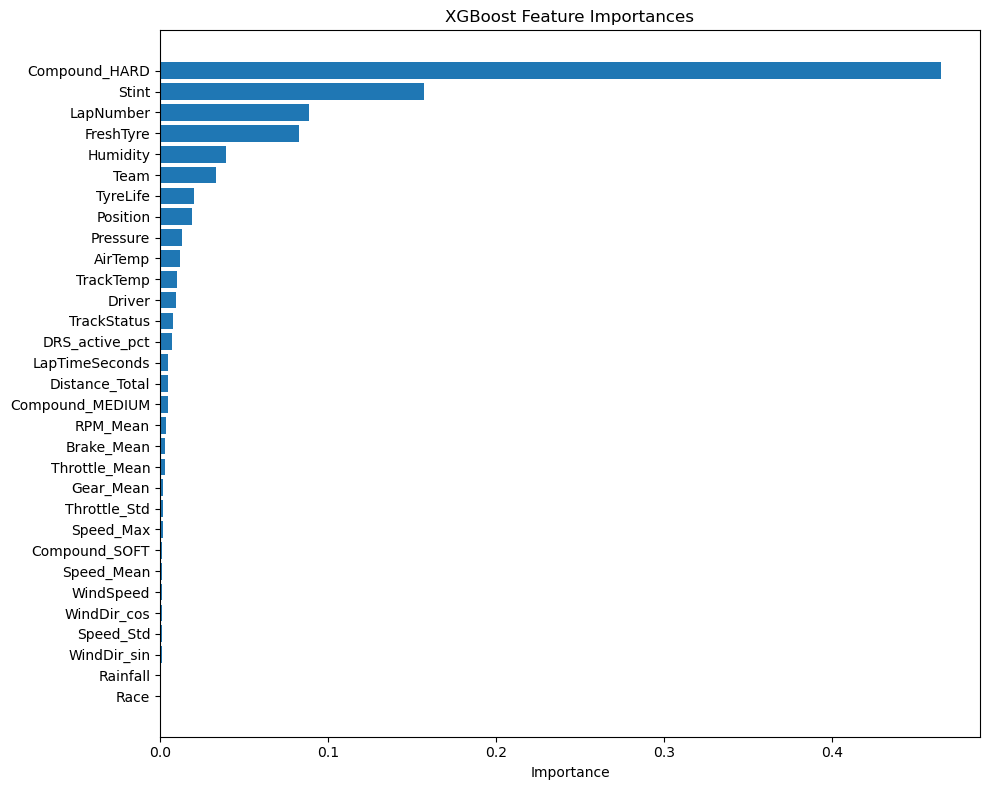

In [130]:
# Get feature importances and sort them
importances = xgb_reg.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.barh(np.array(X_train.columns)[indices], importances[indices])
plt.title("XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

#### Tune regression model

In [131]:
# Set up parameter grid
param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0]
}

In [132]:
# Set up RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_dist,
    n_iter=50,  # number of parameter settings sampled
    scoring='neg_root_mean_squared_error',  # for RMSE
    cv=3,
    verbose=1,
    random_state=111,
    n_jobs=-1
)

# Fit on data
search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,50
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,111
,error_score,nan


In [133]:
best_xgb = search.best_estimator_

print("Best parameters:", search.best_params_)

# Evaluate on validation and test
y_val_pred_tuned = best_xgb.predict(X_val)
y_test_pred_tuned = best_xgb.predict(X_test)

print("Validation Results:")
print(f"RMSE: {root_mean_squared_error(y_val, y_val_pred_tuned):.3f}")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred_tuned):.3f}")
print(f"R2:   {r2_score(y_val, y_val_pred_tuned):.3f}")

print("\nTest Results:")
print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred_tuned):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred_tuned):.3f}")
print(f"R2:   {r2_score(y_test, y_test_pred_tuned):.3f}")

Best parameters: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Validation Results:
RMSE: 2.689
MAE:  1.165
R2:   0.936

Test Results:
RMSE: 3.236
MAE:  1.454
R2:   0.907


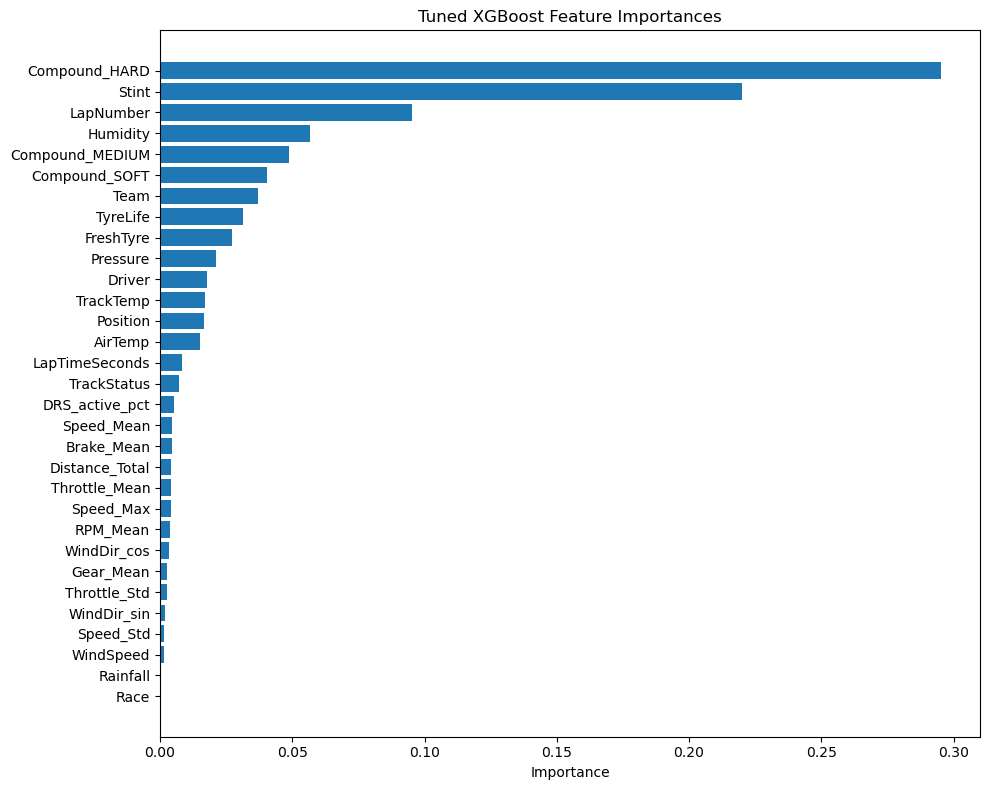

In [134]:
# Get feature importances and sort them
importances_tuned = best_xgb.feature_importances_
indices_tuned = np.argsort(importances_tuned)

plt.figure(figsize=(10, 8))
plt.barh(np.array(X_train.columns)[indices_tuned], importances_tuned[indices_tuned])
plt.title("Tuned XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Result: Poor generalization<br>
Pivot to classification problem, trying to predict whether pit in 5 laps.

#### Reframe as classification task

In [140]:
df_encoded_copy = df_encoded.copy()

In [141]:
# Binary label: 1 if pitting in next 5 laps (including this lap), else 0
df_encoded_copy['PitNext5'] = (df_encoded_copy['LapsTilPit'] <= 5).astype(int)

In [142]:
df_encoded_copy['PitNext5'].value_counts()

PitNext5
0    2679
1     751
Name: count, dtype: int64

In [143]:
feature_cols = [col for col in df_encoded_copy.columns if col not in ['LapsTilPit', 'Year', 'PitNext5']]

# Create a copy to avoid modifying original
X = df_encoded_copy[feature_cols]
y = df_encoded_copy['PitNext5']

# Step 1: Split off test set (15%)
X_temp, X_test_cl, y_temp, y_test_cl = train_test_split(
    X, y,
    test_size=0.15,
    random_state=111,
    stratify=y
)

# Step 2: Split remaining into train and validation (85% → 70/15)
# 0.176 is ~15% of the original full set (0.15 / 0.85)
X_train_cl, X_val_cl, y_train_cl, y_val_cl = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=111,
    stratify=y_temp
)

print("Train:", X_train_cl.shape)
print("Validation:", X_val_cl.shape)
print("Test:", X_test_cl.shape)

Train: (2401, 31)
Validation: (514, 31)
Test: (515, 31)


In [144]:
# # Train, val, test split
# train_df_cl = df_encoded_copy[df_encoded_copy['Year'].isin([2022, 2023])]
# val_df_cl   = df_encoded_copy[df_encoded_copy['Year'] == 2024]
# test_df_cl  = df_encoded_copy[df_encoded_copy['Year'] == 2025]

In [145]:
# # Split sets into features and target
# feature_cols = [col for col in train_df_cl.columns if col not in ['LapsTilPit', 'Year', 'PitNext5']]

# # Training set
# X_train_cl = train_df_cl[feature_cols]
# y_train_cl = train_df_cl['PitNext5']

# # Validation set
# X_val_cl = val_df_cl[feature_cols]
# y_val_cl = val_df_cl['PitNext5']

# # Test set
# X_test_cl = test_df_cl[feature_cols]
# y_test_cl = test_df_cl['PitNext5']

In [146]:
# print(X_train_cl.shape)
# print(y_train_cl.shape)
# print(X_val_cl.shape)
# print(y_val_cl.shape)
# print(X_test_cl.shape)
# print(y_test_cl.shape)

#### Train XGBoost classifier model

In [147]:
# Train
xgb_base_cl = XGBClassifier()
xgb_base_cl.fit(X_train_cl, y_train_cl)

# Predict
y_val_pred_cl = xgb_base_cl.predict(X_val_cl)

# Evaluate
print("XGBoost Classifier Validation Set Performance:\n")
print(confusion_matrix(y_val_cl, y_val_pred_cl))
print(classification_report(y_val_cl, y_val_pred_cl))

XGBoost Classifier Validation Set Performance:

[[394   8]
 [ 11 101]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       402
           1       0.93      0.90      0.91       112

    accuracy                           0.96       514
   macro avg       0.95      0.94      0.95       514
weighted avg       0.96      0.96      0.96       514



#### Tune classifier model

In [148]:
# Class imbalance -> calculate ratio of negative to positive class
ratio = (y_train_cl == 0).sum() / (y_train_cl == 1).sum()
ratio

3.564638783269962

In [149]:
param_grid_cl = {
    'n_estimators': [100, 200, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'scale_pos_weight': [ratio, ratio*0.8, ratio*1.2],
}

In [150]:
search_cl = RandomizedSearchCV(
    xgb_base_cl,
    param_distributions=param_grid_cl,
    n_iter=60,
    scoring='f1_weighted',
    cv=3,
    verbose=1,
    random_state=111,
    n_jobs=-1
)
search_cl.fit(X_train_cl, y_train_cl)

Fitting 3 folds for each of 60 candidates, totalling 180 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,60
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,111
,error_score,nan


In [151]:
best_xgb_cl = search_cl.best_estimator_
y_val_pred_cl_best = best_xgb_cl.predict(X_val_cl)

print(search_cl.best_params_)
print(confusion_matrix(y_val_cl, y_val_pred_cl_best))
print(classification_report(y_val_cl, y_val_pred_cl_best))

{'subsample': 1.0, 'scale_pos_weight': 3.564638783269962, 'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
[[391  11]
 [  7 105]]
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       402
           1       0.91      0.94      0.92       112

    accuracy                           0.96       514
   macro avg       0.94      0.96      0.95       514
weighted avg       0.97      0.96      0.97       514



#### Create more bins

In [152]:
def pit_bin(laps_til_pit):
    if laps_til_pit <= 5:
        return 0
    elif laps_til_pit <= 10:
        return 1
    elif laps_til_pit <= 20:
        return 2
    else:
        return 3

df_encoded_copy['PitBins'], laps_till_pit_bins = pd.qcut(df_encoded_copy['LapsTilPit'], 4, labels=[0,1,2,3], retbins=True)
print('Pit Bins')
laps_till_pit_bins

Pit Bins


array([ 1.,  6., 13., 22., 49.])

In [154]:
print(df_encoded_copy['PitBins'].value_counts().sort_index())

PitBins
0    900
1    903
2    781
3    846
Name: count, dtype: int64


In [155]:
feature_cols = [col for col in df_encoded_copy.columns if col not in ['LapsTilPit', 'Year', 'PitNext5', 'PitBins']]

# Create a copy to avoid modifying original
X = df_encoded_copy[feature_cols]
y = df_encoded_copy['PitBins']

# Step 1: Split off test set (15%)
X_temp, X_test_bins, y_temp, y_test_bins = train_test_split(
    X, y,
    test_size=0.15,
    random_state=111,
    stratify=y
)

# Step 2: Split remaining into train and validation (85% → 70/15)
# 0.176 is ~15% of the original full set (0.15 / 0.85)
X_train_bins, X_val_bins, y_train_bins, y_val_bins = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=111,
    stratify=y_temp
)

print("Train:", X_train_bins.shape)
print("Validation:", X_val_bins.shape)
print("Test:", X_test_bins.shape)

Train: (2401, 31)
Validation: (514, 31)
Test: (515, 31)


In [156]:
# # Train, val, test split
# train_df_bins = df_encoded_copy[df_encoded_copy['Year'].isin([2022, 2023])]
# val_df_bins   = df_encoded_copy[df_encoded_copy['Year'] == 2024]
# test_df_bins  = df_encoded_copy[df_encoded_copy['Year'] == 2025]

In [157]:
# # Split sets into features and target
# feature_cols = [col for col in train_df_bins.columns if col not in ['LapsTilPit', 'Year', 'PitNext5', 'PitBins']]

# # Training set
# X_train_bins = train_df_bins[feature_cols]
# y_train_bins = train_df_bins['PitBins']

# # Validation set
# X_val_bins = val_df_bins[feature_cols]
# y_val_bins = val_df_bins['PitBins']

# # Test set
# X_test_bins = test_df_bins[feature_cols]
# y_test_bins = test_df_bins['PitBins']

#### Train XGB multiclass model

In [158]:
# Train
xgb_multi = XGBClassifier(num_class=4)
xgb_multi.fit(X_train_bins, y_train_bins)

# Predict
y_val_pred_bins = xgb_multi.predict(X_val_bins)

# Evaluate
print("XGBoost Multiclass Validation Set Performance:\n")
print(confusion_matrix(y_val_bins, y_val_pred_bins))
print(classification_report(y_val_bins, y_val_pred_bins))

XGBoost Multiclass Validation Set Performance:

[[117  17   0   1]
 [  7 113  14   1]
 [  1   3 109   4]
 [  2   0   5 120]]
              precision    recall  f1-score   support

           0       0.92      0.87      0.89       135
           1       0.85      0.84      0.84       135
           2       0.85      0.93      0.89       117
           3       0.95      0.94      0.95       127

    accuracy                           0.89       514
   macro avg       0.89      0.90      0.89       514
weighted avg       0.89      0.89      0.89       514



In [159]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

In [160]:
search_mc = RandomizedSearchCV(
    estimator=xgb_multi,
    param_distributions=param_grid,
    n_iter=60,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=111
)
search_mc.fit(X_train_bins, y_train_bins)

Fitting 3 folds for each of 60 candidates, totalling 180 fits


,estimator,"XGBClassifier..._class=4, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,60
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,111
,error_score,nan


In [161]:
best_xgb_multi = search_mc.best_estimator_
y_val_pred_best = best_xgb_multi.predict(X_val_bins)

print("Best parameters:", search_mc.best_params_)
print(confusion_matrix(y_val_bins, y_val_pred_best))
print(classification_report(y_val_bins, y_val_pred_best))

Best parameters: {'subsample': 0.9, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
[[114  19   0   2]
 [  4 117  12   2]
 [  0   3 110   4]
 [  4   0   3 120]]
              precision    recall  f1-score   support

           0       0.93      0.84      0.89       135
           1       0.84      0.87      0.85       135
           2       0.88      0.94      0.91       117
           3       0.94      0.94      0.94       127

    accuracy                           0.90       514
   macro avg       0.90      0.90      0.90       514
weighted avg       0.90      0.90      0.90       514



In [162]:
y_val_test_best = best_xgb_multi.predict(X_test_bins)

print("Best parameters:", search_mc.best_params_)
print(confusion_matrix(y_test_bins, y_val_test_best))
print(classification_report(y_test_bins, y_val_test_best))

Best parameters: {'subsample': 0.9, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
[[120   8   4   3]
 [  7 115  13   1]
 [  0   8 104   5]
 [  0   0   0 127]]
              precision    recall  f1-score   support

           0       0.94      0.89      0.92       135
           1       0.88      0.85      0.86       136
           2       0.86      0.89      0.87       117
           3       0.93      1.00      0.97       127

    accuracy                           0.90       515
   macro avg       0.90      0.91      0.90       515
weighted avg       0.91      0.90      0.90       515




--- WEIGHT ---


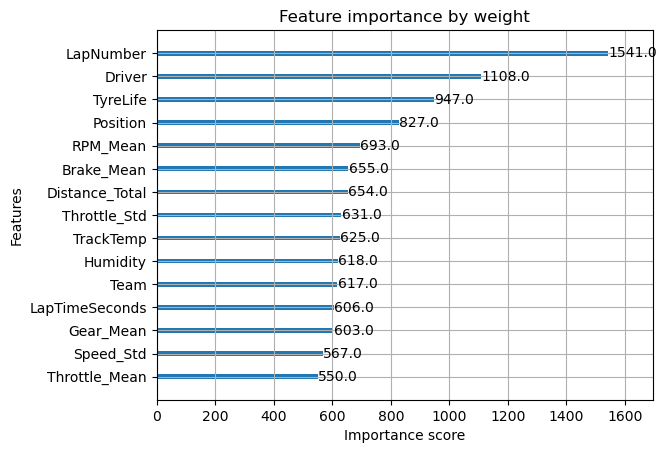


--- GAIN ---


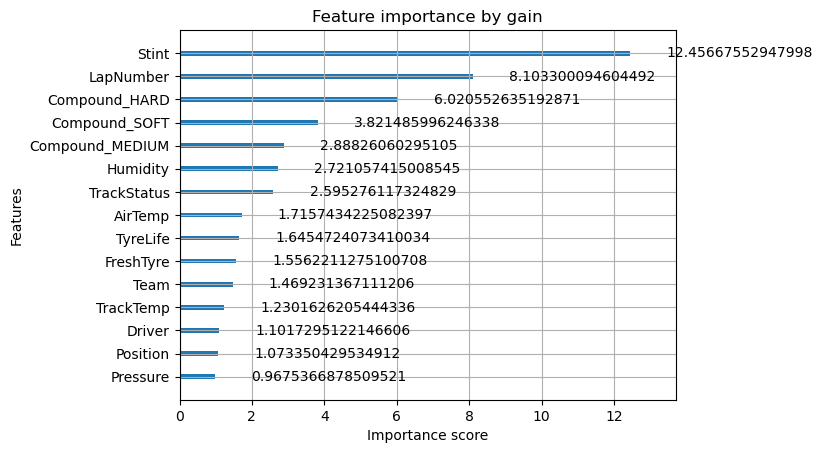


--- COVER ---


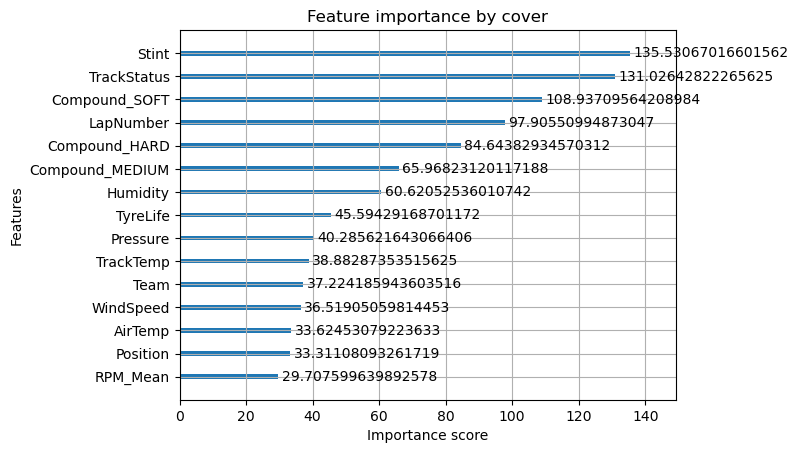

In [163]:
from xgboost import plot_importance

for t in ['weight', 'gain', 'cover']:
    print(f"\n--- {t.upper()} ---")
    plot_importance(best_xgb_multi, importance_type=t, max_num_features=15)
    plt.title(f"Feature importance by {t}")
    plt.show()

### Australia

#### Load cleaned data

In [197]:
df = pd.read_csv('data/f1_laps_australia_clean.csv')

In [198]:
df.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Stint', 'LapTime', 'LapNumber',
       'Position', 'Compound', 'TyreLife', 'FreshTyre', 'TrackStatus',
       'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp',
       'WindDirection', 'WindSpeed', 'Speed_Mean', 'Speed_Max', 'Speed_Std',
       'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'Gear_Mean',
       'Distance_Total', 'DRS_active_pct', 'LapsTilPit'],
      dtype='object')

#### Encode and standardize features

In [199]:
df.dtypes

Driver             object
Team               object
Year                int64
Race               object
Stint             float64
LapTime            object
LapNumber         float64
Position          float64
Compound           object
TyreLife          float64
FreshTyre            bool
TrackStatus         int64
AirTemp           float64
Humidity          float64
Pressure          float64
Rainfall             bool
TrackTemp         float64
WindDirection       int64
WindSpeed         float64
Speed_Mean        float64
Speed_Max         float64
Speed_Std         float64
RPM_Mean          float64
Throttle_Mean     float64
Throttle_Std      float64
Brake_Mean        float64
Gear_Mean         float64
Distance_Total    float64
DRS_active_pct    float64
LapsTilPit        float64
dtype: object

In [200]:
# Turn bool values into int
df['FreshTyre'] = df['FreshTyre'].astype(int)
df['Rainfall'] = df['Rainfall'].astype(int)

In [201]:
ordinal_cols = ['Stint', 'Position']  # leave as is
label = ['LapsTilPit']

label_encode_cols = ['Driver', 'Team', 'Race', 'TrackStatus']
one_hot_cols = ['Compound']

numerical_cols = ['LapTimeSeconds', 'LapNumber', 'TyreLife',
       'AirTemp', 'Humidity', 'Pressure', 'TrackTemp', 'WindSpeed',
       'Speed_Mean', 'Speed_Max', 'Speed_Std', 'Throttle_Mean', 'Throttle_Std',
       'RPM_Mean', 'Brake_Mean', 'Gear_Mean', 'Distance_Total', 'DRS_active_pct']

In [202]:
df_encoded = df.copy()

In [203]:
# Apply cyclical encoding
df_encoded['WindDir_sin'] = np.sin(np.deg2rad(df_encoded['WindDirection']))
df_encoded['WindDir_cos'] = np.cos(np.deg2rad(df_encoded['WindDirection']))

df_encoded = df_encoded.drop(columns=['WindDirection'])

In [204]:
# Label encode
for col in label_encode_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

In [205]:
# One-hot encode
df_encoded = pd.get_dummies(df_encoded, columns=one_hot_cols, drop_first=False)

# Find all new columns created by one-hot encoding
new_cols = [col for col in df_encoded.columns if any(prefix + '_' in col for prefix in one_hot_cols)]

# Cast these columns to int (0/1)
df_encoded[new_cols] = df_encoded[new_cols].astype(int)

In [206]:
df_encoded.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Stint', 'LapTime', 'LapNumber',
       'Position', 'TyreLife', 'FreshTyre', 'TrackStatus', 'AirTemp',
       'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindSpeed',
       'Speed_Mean', 'Speed_Max', 'Speed_Std', 'RPM_Mean', 'Throttle_Mean',
       'Throttle_Std', 'Brake_Mean', 'Gear_Mean', 'Distance_Total',
       'DRS_active_pct', 'LapsTilPit', 'WindDir_sin', 'WindDir_cos',
       'Compound_HARD', 'Compound_INTERMEDIATE', 'Compound_MEDIUM',
       'Compound_SOFT'],
      dtype='object')

In [207]:
df_encoded.loc[0]

Driver                                       25
Team                                         11
Year                                       2022
Race                                          0
Stint                                       1.0
LapTime                  0 days 00:01:30.342000
LapNumber                                   1.0
Position                                    2.0
TyreLife                                    1.0
FreshTyre                                     1
TrackStatus                                   0
AirTemp                                    26.6
Humidity                                   44.0
Pressure                                 1014.4
Rainfall                                      0
TrackTemp                                  39.3
WindSpeed                                   1.7
Speed_Mean                           208.810811
Speed_Max                                 307.0
Speed_Std                              67.01751
RPM_Mean                           10417

In [208]:
# Convert LapTime to seconds
df_encoded['LapTimeSeconds'] = pd.to_timedelta(df_encoded['LapTime']).dt.total_seconds()
df_encoded = df_encoded.drop(columns=['LapTime'])

df_encoded['LapTimeSeconds']

0        90.342
1        93.325
2        92.265
3       100.840
4        99.028
         ...   
3775     89.517
3776     91.312
3777     91.511
3778     90.924
3779     90.553
Name: LapTimeSeconds, Length: 3780, dtype: float64

In [209]:
# Standardize numerical columns
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

In [210]:
df_encoded[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
LapTimeSeconds,3780.0,-1.007542e-15,1.000132,-0.740493,-0.556804,-0.446526,0.057517,3.781459
LapNumber,3780.0,-3.759485e-17,1.000132,-1.704897,-0.840318,-0.037495,0.827085,1.815175
TyreLife,3780.0,4.511382e-17,1.000132,-1.297978,-0.794865,-0.248003,0.626975,3.601903
AirTemp,3780.0,2.105312e-16,1.000132,-1.327571,-0.761181,-0.029593,1.362783,1.575180
Humidity,3780.0,-1.804553e-16,1.000132,-0.984262,-0.751633,-0.596547,0.333968,2.350084
Pressure,3780.0,8.782158e-15,1.000132,-1.584613,-0.485176,0.561907,1.033094,1.294865
TrackTemp,3780.0,-1.503794e-16,1.000132,-1.767873,-0.351525,0.437583,0.822021,1.010867
WindSpeed,3780.0,3.007588e-17,1.000132,-1.602292,-0.719611,-0.327308,0.359222,3.399567
Speed_Mean,3780.0,3.458727e-16,1.000132,-3.185500,-0.221962,0.440074,0.636064,1.005998
Speed_Max,3780.0,4.285813e-16,1.000132,-6.609374,-0.218470,0.059396,0.406727,2.421251


#### Split into train, val, and test sets

In [213]:
feature_cols = [col for col in df_encoded.columns if col not in ['LapsTilPit', 'Year']]

# Create a copy to avoid modifying original
X = df_encoded[feature_cols]
y = df_encoded['LapsTilPit']

# Step 1: Split off test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=111
)

# Step 2: Split remaining into train and validation (85% → 70/15)
# 0.176 is ~15% of the original full set (0.15 / 0.85)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=111
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (2647, 32)
Validation: (566, 32)
Test: (567, 32)


In [214]:
# # Train, val, test split
# train_df = df_encoded[df_encoded['Year'].isin([2022, 2023])]
# val_df   = df_encoded[df_encoded['Year'] == 2024]
# test_df  = df_encoded[df_encoded['Year'] == 2025]

In [215]:
# print(train_df.shape)
# print(val_df.shape)
# print(test_df.shape)

In [216]:
# # Split sets into features and target
# feature_cols = [col for col in train_df.columns if col not in ['LapsTilPit', 'Year']]

# # Training set
# X_train = train_df[feature_cols]
# y_train = train_df['LapsTilPit']

# # Validation set
# X_val = val_df[feature_cols]
# y_val = val_df['LapsTilPit']

# # Test set
# X_test = test_df[feature_cols]
# y_test = test_df['LapsTilPit']

In [217]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(2647, 32)
(2647,)
(566, 32)
(566,)
(567, 32)
(567,)


#### Train XGBoost regression model

In [218]:
# Train XGBoost regressor
xgb_reg = XGBRegressor()
xgb_reg.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=True)

[0]	validation_0-rmse:8.82266
[1]	validation_0-rmse:7.27702
[2]	validation_0-rmse:6.04232
[3]	validation_0-rmse:5.25819
[4]	validation_0-rmse:4.66791


[5]	validation_0-rmse:4.31038
[6]	validation_0-rmse:4.00322
[7]	validation_0-rmse:3.71556
[8]	validation_0-rmse:3.51705
[9]	validation_0-rmse:3.43035
[10]	validation_0-rmse:3.26612
[11]	validation_0-rmse:3.20761
[12]	validation_0-rmse:3.14796
[13]	validation_0-rmse:3.09877
[14]	validation_0-rmse:3.01589
[15]	validation_0-rmse:2.94419
[16]	validation_0-rmse:2.90071
[17]	validation_0-rmse:2.86009
[18]	validation_0-rmse:2.82884
[19]	validation_0-rmse:2.81334
[20]	validation_0-rmse:2.79471
[21]	validation_0-rmse:2.74679
[22]	validation_0-rmse:2.74034
[23]	validation_0-rmse:2.71466
[24]	validation_0-rmse:2.69307
[25]	validation_0-rmse:2.69267
[26]	validation_0-rmse:2.66669
[27]	validation_0-rmse:2.64203
[28]	validation_0-rmse:2.63778
[29]	validation_0-rmse:2.62435
[30]	validation_0-rmse:2.62471
[31]	validation_0-rmse:2.60672
[32]	validation_0-rmse:2.60496
[33]	validation_0-rmse:2.59583
[34]	validation_0-rmse:2.60233
[35]	validation_0-rmse:2.59709
[36]	validation_0-rmse:2.59244
[37]	validati

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [219]:
# Predict
y_val_pred = xgb_reg.predict(X_val)
y_test_pred = xgb_reg.predict(X_test)

# Evaluate
print("Validation Results:")
print(f"RMSE: {root_mean_squared_error(y_val, y_val_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred):.3f}")
print(f"R2:   {r2_score(y_val, y_val_pred):.3f}")

print("\nTest Results:")
print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred):.3f}")
print(f"R2:   {r2_score(y_test, y_test_pred):.3f}")

Validation Results:
RMSE: 2.510
MAE:  1.319
R2:   0.950

Test Results:
RMSE: 2.017
MAE:  1.165
R2:   0.965


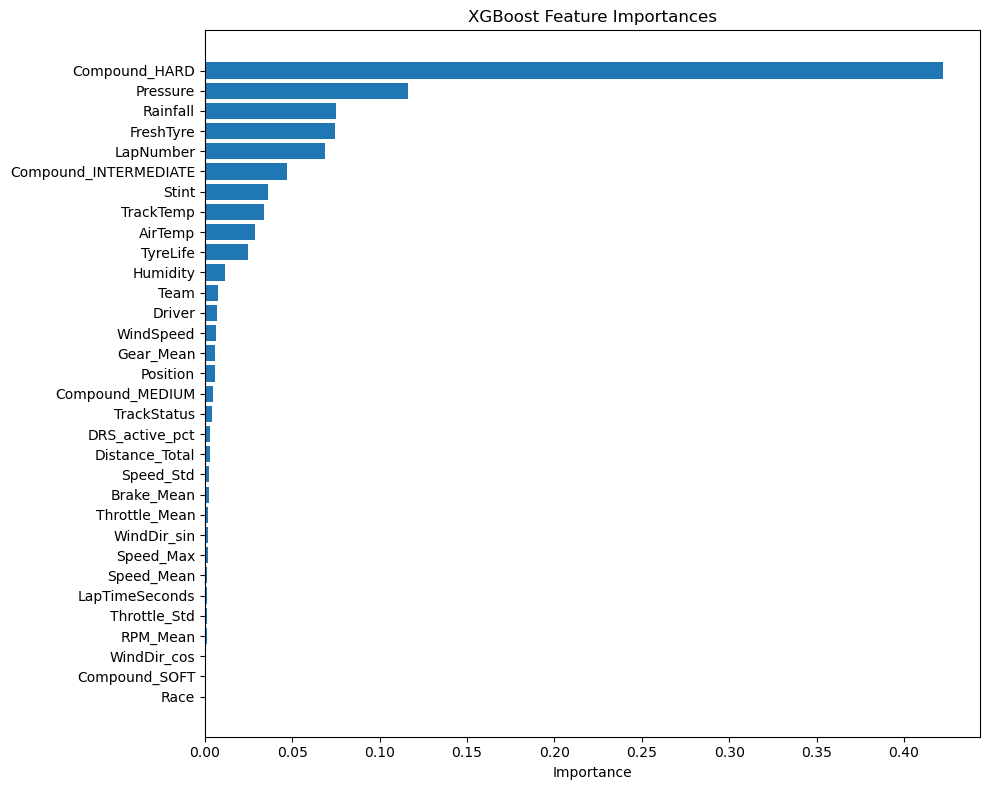

In [220]:
# Get feature importances and sort them
importances = xgb_reg.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.barh(np.array(X_train.columns)[indices], importances[indices])
plt.title("XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

#### Tune regression model

In [221]:
# Set up parameter grid
param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0]
}

In [222]:
# Set up RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_dist,
    n_iter=50,  # number of parameter settings sampled
    scoring='neg_root_mean_squared_error',  # for RMSE
    cv=3,
    verbose=1,
    random_state=111,
    n_jobs=-1
)

# Fit on data
search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,50
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,111
,error_score,nan


In [223]:
best_xgb = search.best_estimator_

print("Best parameters:", search.best_params_)

# Evaluate on validation and test
y_val_pred_tuned = best_xgb.predict(X_val)
y_test_pred_tuned = best_xgb.predict(X_test)

print("Validation Results:")
print(f"RMSE: {root_mean_squared_error(y_val, y_val_pred_tuned):.3f}")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred_tuned):.3f}")
print(f"R2:   {r2_score(y_val, y_val_pred_tuned):.3f}")

print("\nTest Results:")
print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred_tuned):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred_tuned):.3f}")
print(f"R2:   {r2_score(y_test, y_test_pred_tuned):.3f}")

Best parameters: {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Validation Results:
RMSE: 2.340
MAE:  1.053
R2:   0.956

Test Results:
RMSE: 1.579
MAE:  0.912
R2:   0.979


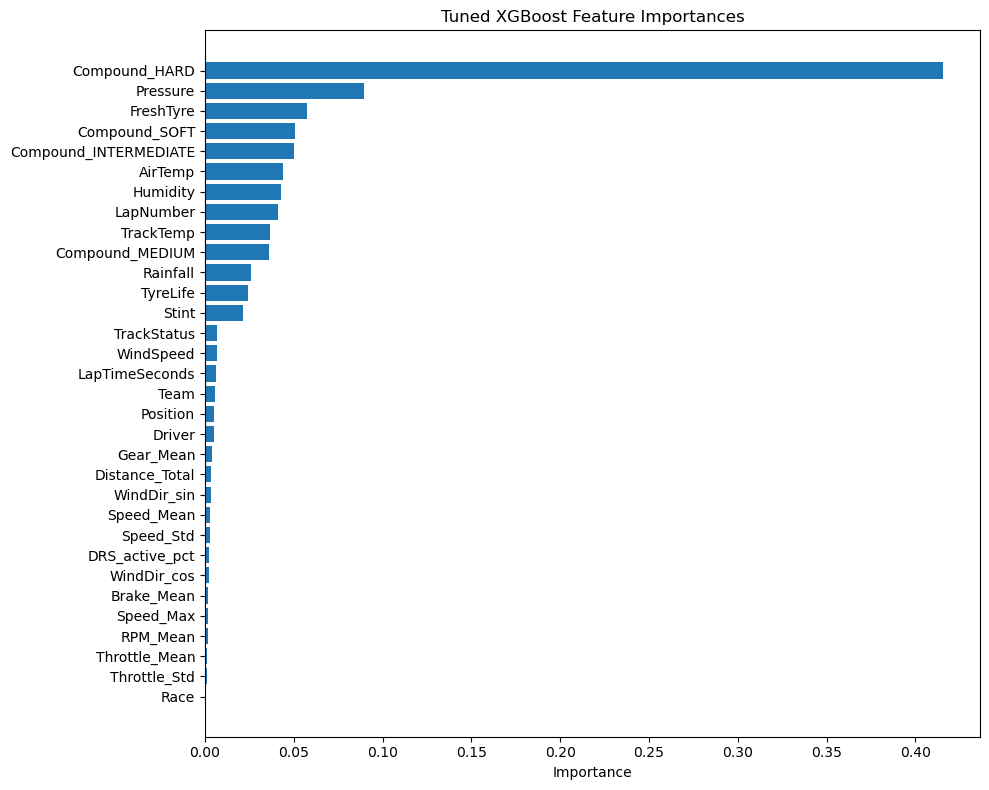

In [224]:
# Get feature importances and sort them
importances_tuned = best_xgb.feature_importances_
indices_tuned = np.argsort(importances_tuned)

plt.figure(figsize=(10, 8))
plt.barh(np.array(X_train.columns)[indices_tuned], importances_tuned[indices_tuned])
plt.title("Tuned XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Result: Poor generalization<br>
Pivot to classification problem, trying to predict whether pit in 5 laps.

#### Reframe as classification task

In [225]:
df_encoded_copy = df_encoded.copy()

In [226]:
# Binary label: 1 if pitting in next 5 laps (including this lap), else 0
df_encoded_copy['PitNext5'] = (df_encoded_copy['LapsTilPit'] <= 5).astype(int)

In [227]:
df_encoded_copy['PitNext5'].value_counts()

PitNext5
0    2907
1     873
Name: count, dtype: int64

In [228]:
feature_cols = [col for col in df_encoded_copy.columns if col not in ['LapsTilPit', 'Year', 'PitNext5']]

# Create a copy to avoid modifying original
X = df_encoded_copy[feature_cols]
y = df_encoded_copy['PitNext5']

# Step 1: Split off test set (15%)
X_temp, X_test_cl, y_temp, y_test_cl = train_test_split(
    X, y,
    test_size=0.15,
    random_state=111,
    stratify=y
)

# Step 2: Split remaining into train and validation (85% → 70/15)
# 0.176 is ~15% of the original full set (0.15 / 0.85)
X_train_cl, X_val_cl, y_train_cl, y_val_cl = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=111,
    stratify=y_temp
)

print("Train:", X_train_cl.shape)
print("Validation:", X_val_cl.shape)
print("Test:", X_test_cl.shape)

Train: (2647, 32)
Validation: (566, 32)
Test: (567, 32)


In [229]:
# # Train, val, test split
# train_df_cl = df_encoded_copy[df_encoded_copy['Year'].isin([2022, 2023])]
# val_df_cl   = df_encoded_copy[df_encoded_copy['Year'] == 2024]
# test_df_cl  = df_encoded_copy[df_encoded_copy['Year'] == 2025]

In [230]:
# # Split sets into features and target
# feature_cols = [col for col in train_df_cl.columns if col not in ['LapsTilPit', 'Year', 'PitNext5']]

# # Training set
# X_train_cl = train_df_cl[feature_cols]
# y_train_cl = train_df_cl['PitNext5']

# # Validation set
# X_val_cl = val_df_cl[feature_cols]
# y_val_cl = val_df_cl['PitNext5']

# # Test set
# X_test_cl = test_df_cl[feature_cols]
# y_test_cl = test_df_cl['PitNext5']

In [231]:
# print(X_train_cl.shape)
# print(y_train_cl.shape)
# print(X_val_cl.shape)
# print(y_val_cl.shape)
# print(X_test_cl.shape)
# print(y_test_cl.shape)

#### Train XGBoost classifier model

In [232]:
# Train
xgb_base_cl = XGBClassifier()
xgb_base_cl.fit(X_train_cl, y_train_cl)

# Predict
y_val_pred_cl = xgb_base_cl.predict(X_val_cl)

# Evaluate
print("XGBoost Classifier Validation Set Performance:\n")
print(confusion_matrix(y_val_cl, y_val_pred_cl))
print(classification_report(y_val_cl, y_val_pred_cl))

XGBoost Classifier Validation Set Performance:

[[429   6]
 [ 20 111]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       435
           1       0.95      0.85      0.90       131

    accuracy                           0.95       566
   macro avg       0.95      0.92      0.93       566
weighted avg       0.95      0.95      0.95       566



#### Tune classifier model

In [233]:
# Class imbalance -> calculate ratio of negative to positive class
ratio = (y_train_cl == 0).sum() / (y_train_cl == 1).sum()
ratio

3.3322422258592472

In [234]:
param_grid_cl = {
    'n_estimators': [100, 200, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'scale_pos_weight': [ratio, ratio*0.8, ratio*1.2],
}

In [235]:
search_cl = RandomizedSearchCV(
    xgb_base_cl,
    param_distributions=param_grid_cl,
    n_iter=60,
    scoring='f1_weighted',
    cv=3,
    verbose=1,
    random_state=111,
    n_jobs=-1
)
search_cl.fit(X_train_cl, y_train_cl)

Fitting 3 folds for each of 60 candidates, totalling 180 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,60
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,111
,error_score,nan


In [236]:
best_xgb_cl = search_cl.best_estimator_
y_val_pred_cl_best = best_xgb_cl.predict(X_val_cl)

print(search_cl.best_params_)
print(confusion_matrix(y_val_cl, y_val_pred_cl_best))
print(classification_report(y_val_cl, y_val_pred_cl_best))

{'subsample': 0.9, 'scale_pos_weight': 3.3322422258592472, 'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
[[427   8]
 [ 13 118]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       435
           1       0.94      0.90      0.92       131

    accuracy                           0.96       566
   macro avg       0.95      0.94      0.95       566
weighted avg       0.96      0.96      0.96       566



#### Create more bins

In [237]:
def pit_bin(laps_til_pit):
    if laps_til_pit <= 5:
        return 0
    elif laps_til_pit <= 10:
        return 1
    elif laps_til_pit <= 20:
        return 2
    else:
        return 3

df_encoded_copy['PitBins'], laps_till_pit_bins = pd.qcut(df_encoded_copy['LapsTilPit'], 4, labels=[0,1,2,3], retbins=True)
print('Pit Bins')
laps_till_pit_bins

Pit Bins


array([ 1.,  6., 12., 22., 57.])

In [238]:
print(df_encoded_copy['PitBins'].value_counts().sort_index())

PitBins
0    1047
1     864
2     980
3     889
Name: count, dtype: int64


In [239]:
feature_cols = [col for col in df_encoded_copy.columns if col not in ['LapsTilPit', 'Year', 'PitNext5', 'PitBins']]

# Create a copy to avoid modifying original
X = df_encoded_copy[feature_cols]
y = df_encoded_copy['PitBins']

# Step 1: Split off test set (15%)
X_temp, X_test_bins, y_temp, y_test_bins = train_test_split(
    X, y,
    test_size=0.15,
    random_state=111,
    stratify=y
)

# Step 2: Split remaining into train and validation (85% → 70/15)
# 0.176 is ~15% of the original full set (0.15 / 0.85)
X_train_bins, X_val_bins, y_train_bins, y_val_bins = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=111,
    stratify=y_temp
)

print("Train:", X_train_bins.shape)
print("Validation:", X_val_bins.shape)
print("Test:", X_test_bins.shape)

Train: (2647, 32)
Validation: (566, 32)
Test: (567, 32)


In [240]:
# # Train, val, test split
# train_df_bins = df_encoded_copy[df_encoded_copy['Year'].isin([2022, 2023])]
# val_df_bins   = df_encoded_copy[df_encoded_copy['Year'] == 2024]
# test_df_bins  = df_encoded_copy[df_encoded_copy['Year'] == 2025]

In [241]:
# # Split sets into features and target
# feature_cols = [col for col in train_df_bins.columns if col not in ['LapsTilPit', 'Year', 'PitNext5', 'PitBins']]

# # Training set
# X_train_bins = train_df_bins[feature_cols]
# y_train_bins = train_df_bins['PitBins']

# # Validation set
# X_val_bins = val_df_bins[feature_cols]
# y_val_bins = val_df_bins['PitBins']

# # Test set
# X_test_bins = test_df_bins[feature_cols]
# y_test_bins = test_df_bins['PitBins']

#### Train XGB multiclass model

In [242]:
# Train
xgb_multi = XGBClassifier(num_class=4)
xgb_multi.fit(X_train_bins, y_train_bins)

# Predict
y_val_pred_bins = xgb_multi.predict(X_val_bins)

# Evaluate
print("XGBoost Multiclass Validation Set Performance:\n")
print(confusion_matrix(y_val_bins, y_val_pred_bins))
print(classification_report(y_val_bins, y_val_pred_bins))

XGBoost Multiclass Validation Set Performance:

[[147   5   5   0]
 [ 18 103   7   1]
 [  1  17 121   8]
 [  0   2   8 123]]
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       157
           1       0.81      0.80      0.80       129
           2       0.86      0.82      0.84       147
           3       0.93      0.92      0.93       133

    accuracy                           0.87       566
   macro avg       0.87      0.87      0.87       566
weighted avg       0.87      0.87      0.87       566



In [243]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

In [244]:
search_mc = RandomizedSearchCV(
    estimator=xgb_multi,
    param_distributions=param_grid,
    n_iter=60,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=111
)
search_mc.fit(X_train_bins, y_train_bins)

Fitting 3 folds for each of 60 candidates, totalling 180 fits


,estimator,"XGBClassifier..._class=4, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,60
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,111
,error_score,nan


In [245]:
best_xgb_multi = search_mc.best_estimator_
y_val_pred_best = best_xgb_multi.predict(X_val_bins)

print("Best parameters:", search_mc.best_params_)
print(confusion_matrix(y_val_bins, y_val_pred_best))
print(classification_report(y_val_bins, y_val_pred_best))

Best parameters: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
[[148   3   6   0]
 [ 22 104   3   0]
 [  1  16 122   8]
 [  0   1   9 123]]
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       157
           1       0.84      0.81      0.82       129
           2       0.87      0.83      0.85       147
           3       0.94      0.92      0.93       133

    accuracy                           0.88       566
   macro avg       0.88      0.88      0.88       566
weighted avg       0.88      0.88      0.88       566



In [246]:
y_val_test_best = best_xgb_multi.predict(X_test_bins)

print("Best parameters:", search_mc.best_params_)
print(confusion_matrix(y_test_bins, y_val_test_best))
print(classification_report(y_test_bins, y_val_test_best))

Best parameters: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
[[142  10   4   1]
 [ 13 111   6   0]
 [  5   8 128   6]
 [  0   1   9 123]]
              precision    recall  f1-score   support

           0       0.89      0.90      0.90       157
           1       0.85      0.85      0.85       130
           2       0.87      0.87      0.87       147
           3       0.95      0.92      0.94       133

    accuracy                           0.89       567
   macro avg       0.89      0.89      0.89       567
weighted avg       0.89      0.89      0.89       567




--- WEIGHT ---


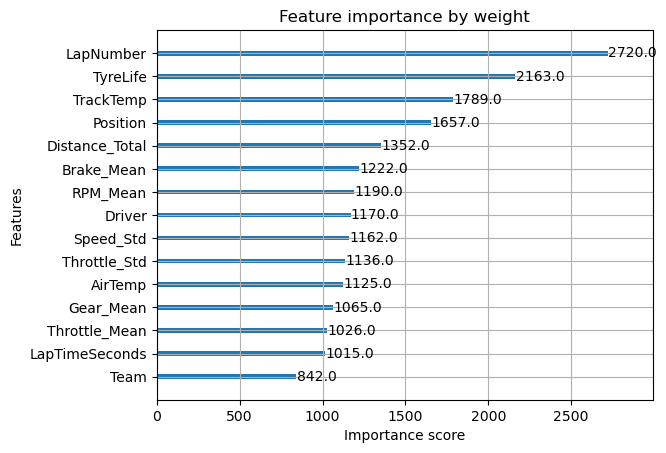


--- GAIN ---


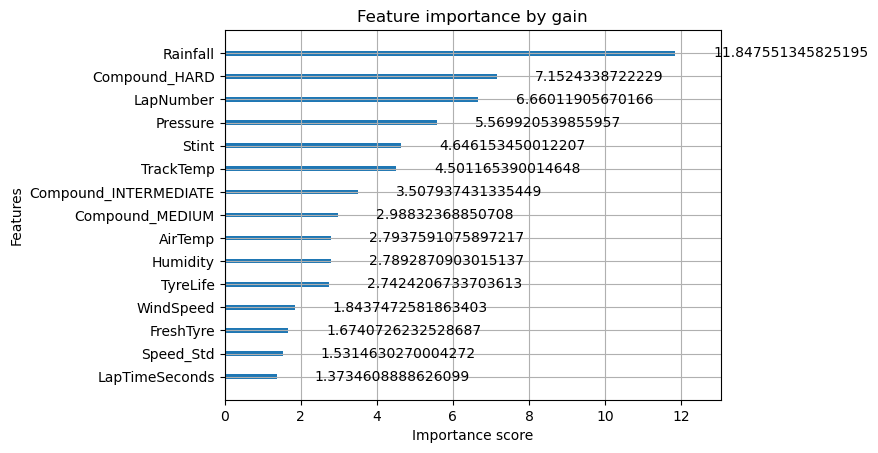


--- COVER ---


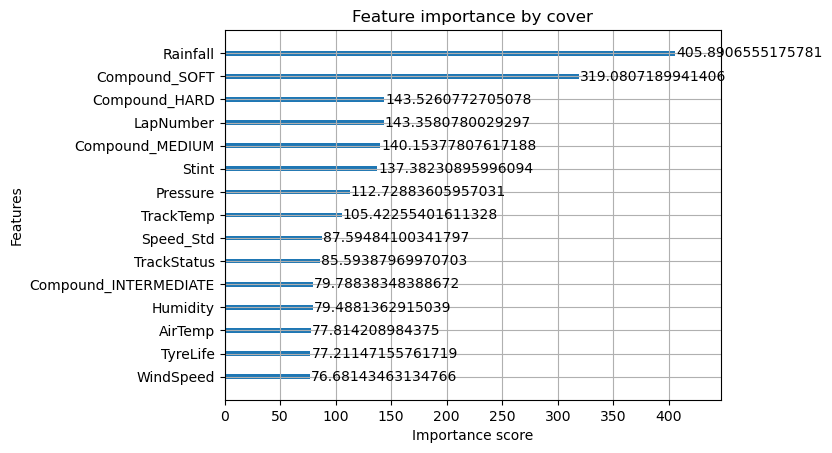

In [247]:
from xgboost import plot_importance

for t in ['weight', 'gain', 'cover']:
    print(f"\n--- {t.upper()} ---")
    plot_importance(best_xgb_multi, importance_type=t, max_num_features=15)
    plt.title(f"Feature importance by {t}")
    plt.show()

### Bahrain

#### Load cleaned data

In [248]:
df = pd.read_csv('data/f1_laps_bahrain_clean.csv')

In [249]:
df.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Stint', 'LapTime', 'LapNumber',
       'Position', 'Compound', 'TyreLife', 'FreshTyre', 'TrackStatus',
       'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp',
       'WindDirection', 'WindSpeed', 'Speed_Mean', 'Speed_Max', 'Speed_Std',
       'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'Gear_Mean',
       'Distance_Total', 'DRS_active_pct', 'LapsTilPit'],
      dtype='object')

#### Encode and standardize features

In [250]:
df.dtypes

Driver             object
Team               object
Year                int64
Race               object
Stint             float64
LapTime            object
LapNumber         float64
Position          float64
Compound           object
TyreLife          float64
FreshTyre            bool
TrackStatus         int64
AirTemp           float64
Humidity          float64
Pressure          float64
Rainfall             bool
TrackTemp         float64
WindDirection       int64
WindSpeed         float64
Speed_Mean        float64
Speed_Max         float64
Speed_Std         float64
RPM_Mean          float64
Throttle_Mean     float64
Throttle_Std      float64
Brake_Mean        float64
Gear_Mean         float64
Distance_Total    float64
DRS_active_pct    float64
LapsTilPit        float64
dtype: object

In [251]:
# Turn bool values into int
df['FreshTyre'] = df['FreshTyre'].astype(int)
df['Rainfall'] = df['Rainfall'].astype(int)

In [252]:
ordinal_cols = ['Stint', 'Position']  # leave as is
label = ['LapsTilPit']

label_encode_cols = ['Driver', 'Team', 'Race', 'TrackStatus']
one_hot_cols = ['Compound']

numerical_cols = ['LapTimeSeconds', 'LapNumber', 'TyreLife',
       'AirTemp', 'Humidity', 'Pressure', 'TrackTemp', 'WindSpeed',
       'Speed_Mean', 'Speed_Max', 'Speed_Std', 'Throttle_Mean', 'Throttle_Std',
       'RPM_Mean', 'Brake_Mean', 'Gear_Mean', 'Distance_Total', 'DRS_active_pct']

In [253]:
df_encoded = df.copy()

In [254]:
# Apply cyclical encoding
df_encoded['WindDir_sin'] = np.sin(np.deg2rad(df_encoded['WindDirection']))
df_encoded['WindDir_cos'] = np.cos(np.deg2rad(df_encoded['WindDirection']))

df_encoded = df_encoded.drop(columns=['WindDirection'])

In [255]:
# Label encode
for col in label_encode_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

In [256]:
# One-hot encode
df_encoded = pd.get_dummies(df_encoded, columns=one_hot_cols, drop_first=False)

# Find all new columns created by one-hot encoding
new_cols = [col for col in df_encoded.columns if any(prefix + '_' in col for prefix in one_hot_cols)]

# Cast these columns to int (0/1)
df_encoded[new_cols] = df_encoded[new_cols].astype(int)

In [257]:
df_encoded.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Stint', 'LapTime', 'LapNumber',
       'Position', 'TyreLife', 'FreshTyre', 'TrackStatus', 'AirTemp',
       'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindSpeed',
       'Speed_Mean', 'Speed_Max', 'Speed_Std', 'RPM_Mean', 'Throttle_Mean',
       'Throttle_Std', 'Brake_Mean', 'Gear_Mean', 'Distance_Total',
       'DRS_active_pct', 'LapsTilPit', 'WindDir_sin', 'WindDir_cos',
       'Compound_HARD', 'Compound_MEDIUM', 'Compound_SOFT'],
      dtype='object')

In [258]:
df_encoded.loc[0]

Driver                                 27
Team                                   11
Year                                 2022
Race                                    0
Stint                                 1.0
LapTime            0 days 00:01:40.236000
LapNumber                             1.0
Position                              2.0
TyreLife                              4.0
FreshTyre                               0
TrackStatus                             0
AirTemp                              23.9
Humidity                             25.0
Pressure                           1010.2
Rainfall                                0
TrackTemp                            29.1
WindSpeed                             0.5
Speed_Mean                     183.433962
Speed_Max                           286.0
Speed_Std                       66.059742
RPM_Mean                     10247.797844
Throttle_Mean                   61.336927
Throttle_Std                    43.993946
Brake_Mean                       0

In [259]:
# Convert LapTime to seconds
df_encoded['LapTimeSeconds'] = pd.to_timedelta(df_encoded['LapTime']).dt.total_seconds()
df_encoded = df_encoded.drop(columns=['LapTime'])

df_encoded['LapTimeSeconds']

0       100.236
1       101.006
2       108.826
3       104.270
4       101.555
         ...   
4409     98.823
4410     98.496
4411     98.750
4412     98.980
4413     99.063
Name: LapTimeSeconds, Length: 4414, dtype: float64

In [260]:
# Standardize numerical columns
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

In [261]:
df_encoded[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
LapTimeSeconds,4414.0,1.480968e-15,1.000113,-1.062771,-0.411990,-0.275631,-0.072696,6.574277
LapNumber,4414.0,-9.014588e-17,1.000113,-1.682693,-0.886858,-0.029805,0.827249,1.745520
TyreLife,4414.0,-2.575597e-17,1.000113,-1.515651,-0.863628,-0.048599,0.603424,3.374523
AirTemp,4414.0,-7.726790e-17,1.000113,-1.643815,-1.451182,0.089883,0.887934,1.025529
Humidity,4414.0,0.000000e+00,1.000113,-1.646995,-1.017541,0.421212,0.960744,1.140588
Pressure,4414.0,9.503952e-15,1.000113,-1.308262,-1.182691,-0.630177,0.977134,1.077591
TrackTemp,4414.0,3.605835e-16,1.000113,-1.801098,-1.217419,0.318578,0.871538,1.363057
WindSpeed,4414.0,-1.030239e-16,1.000113,-1.058580,-0.659647,-0.393691,0.404175,3.196708
Speed_Mean,4414.0,-9.014588e-17,1.000113,-5.325938,-0.003052,0.270979,0.482092,2.079213
Speed_Max,4414.0,1.146141e-15,1.000113,-10.804221,-0.396657,-0.047410,0.231987,2.537018


#### Split into train, val, and test sets

In [262]:
feature_cols = [col for col in df_encoded.columns if col not in ['LapsTilPit', 'Year']]

# Create a copy to avoid modifying original
X = df_encoded[feature_cols]
y = df_encoded['LapsTilPit']

# Step 1: Split off test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=111
)

# Step 2: Split remaining into train and validation (85% → 70/15)
# 0.176 is ~15% of the original full set (0.15 / 0.85)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=111
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (3090, 31)
Validation: (661, 31)
Test: (663, 31)


In [263]:
# # Train, val, test split
# train_df = df_encoded[df_encoded['Year'].isin([2022, 2023])]
# val_df   = df_encoded[df_encoded['Year'] == 2024]
# test_df  = df_encoded[df_encoded['Year'] == 2025]

In [264]:
# print(train_df.shape)
# print(val_df.shape)
# print(test_df.shape)

In [265]:
# # Split sets into features and target
# feature_cols = [col for col in train_df.columns if col not in ['LapsTilPit', 'Year']]

# # Training set
# X_train = train_df[feature_cols]
# y_train = train_df['LapsTilPit']

# # Validation set
# X_val = val_df[feature_cols]
# y_val = val_df['LapsTilPit']

# # Test set
# X_test = test_df[feature_cols]
# y_test = test_df['LapsTilPit']

In [266]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(3090, 31)
(3090,)
(661, 31)
(661,)
(663, 31)
(663,)


#### Train XGBoost regression model

In [267]:
# Train XGBoost regressor
xgb_reg = XGBRegressor()
xgb_reg.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=True)

[0]	validation_0-rmse:5.10874
[1]	validation_0-rmse:4.25505
[2]	validation_0-rmse:3.77449
[3]	validation_0-rmse:3.45933
[4]	validation_0-rmse:3.21652
[5]	validation_0-rmse:3.04965
[6]	validation_0-rmse:2.94287


[7]	validation_0-rmse:2.87832
[8]	validation_0-rmse:2.82301
[9]	validation_0-rmse:2.79842
[10]	validation_0-rmse:2.75653
[11]	validation_0-rmse:2.74043
[12]	validation_0-rmse:2.67317
[13]	validation_0-rmse:2.64256
[14]	validation_0-rmse:2.59681
[15]	validation_0-rmse:2.58328
[16]	validation_0-rmse:2.56964
[17]	validation_0-rmse:2.54220
[18]	validation_0-rmse:2.53814
[19]	validation_0-rmse:2.48485
[20]	validation_0-rmse:2.47647
[21]	validation_0-rmse:2.47976
[22]	validation_0-rmse:2.47512
[23]	validation_0-rmse:2.46954
[24]	validation_0-rmse:2.44632
[25]	validation_0-rmse:2.44017
[26]	validation_0-rmse:2.42704
[27]	validation_0-rmse:2.42650
[28]	validation_0-rmse:2.42541
[29]	validation_0-rmse:2.41817
[30]	validation_0-rmse:2.40785
[31]	validation_0-rmse:2.37964
[32]	validation_0-rmse:2.36377
[33]	validation_0-rmse:2.34099
[34]	validation_0-rmse:2.34207
[35]	validation_0-rmse:2.32332
[36]	validation_0-rmse:2.30380
[37]	validation_0-rmse:2.28401
[38]	validation_0-rmse:2.27537
[39]	valida

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [268]:
# Predict
y_val_pred = xgb_reg.predict(X_val)
y_test_pred = xgb_reg.predict(X_test)

# Evaluate
print("Validation Results:")
print(f"RMSE: {root_mean_squared_error(y_val, y_val_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred):.3f}")
print(f"R2:   {r2_score(y_val, y_val_pred):.3f}")

print("\nTest Results:")
print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred):.3f}")
print(f"R2:   {r2_score(y_test, y_test_pred):.3f}")

Validation Results:
RMSE: 2.204
MAE:  1.418
R2:   0.880

Test Results:
RMSE: 1.895
MAE:  1.280
R2:   0.905


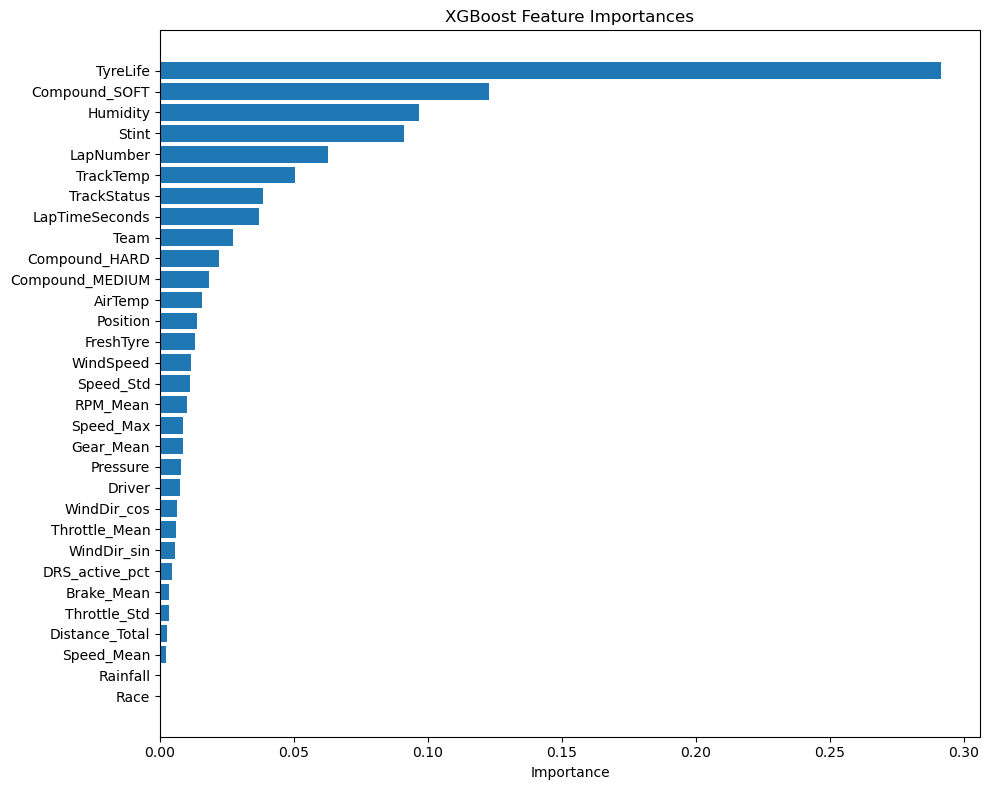

In [269]:
# Get feature importances and sort them
importances = xgb_reg.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.barh(np.array(X_train.columns)[indices], importances[indices])
plt.title("XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

#### Tune regression model

In [270]:
# Set up parameter grid
param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0]
}

In [271]:
# Set up RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_dist,
    n_iter=50,  # number of parameter settings sampled
    scoring='neg_root_mean_squared_error',  # for RMSE
    cv=3,
    verbose=1,
    random_state=111,
    n_jobs=-1
)

# Fit on data
search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,50
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,111
,error_score,nan


In [272]:
best_xgb = search.best_estimator_

print("Best parameters:", search.best_params_)

# Evaluate on validation and test
y_val_pred_tuned = best_xgb.predict(X_val)
y_test_pred_tuned = best_xgb.predict(X_test)

print("Validation Results:")
print(f"RMSE: {root_mean_squared_error(y_val, y_val_pred_tuned):.3f}")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred_tuned):.3f}")
print(f"R2:   {r2_score(y_val, y_val_pred_tuned):.3f}")

print("\nTest Results:")
print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred_tuned):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred_tuned):.3f}")
print(f"R2:   {r2_score(y_test, y_test_pred_tuned):.3f}")

Best parameters: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Validation Results:
RMSE: 1.867
MAE:  1.169
R2:   0.914

Test Results:
RMSE: 1.744
MAE:  1.086
R2:   0.919


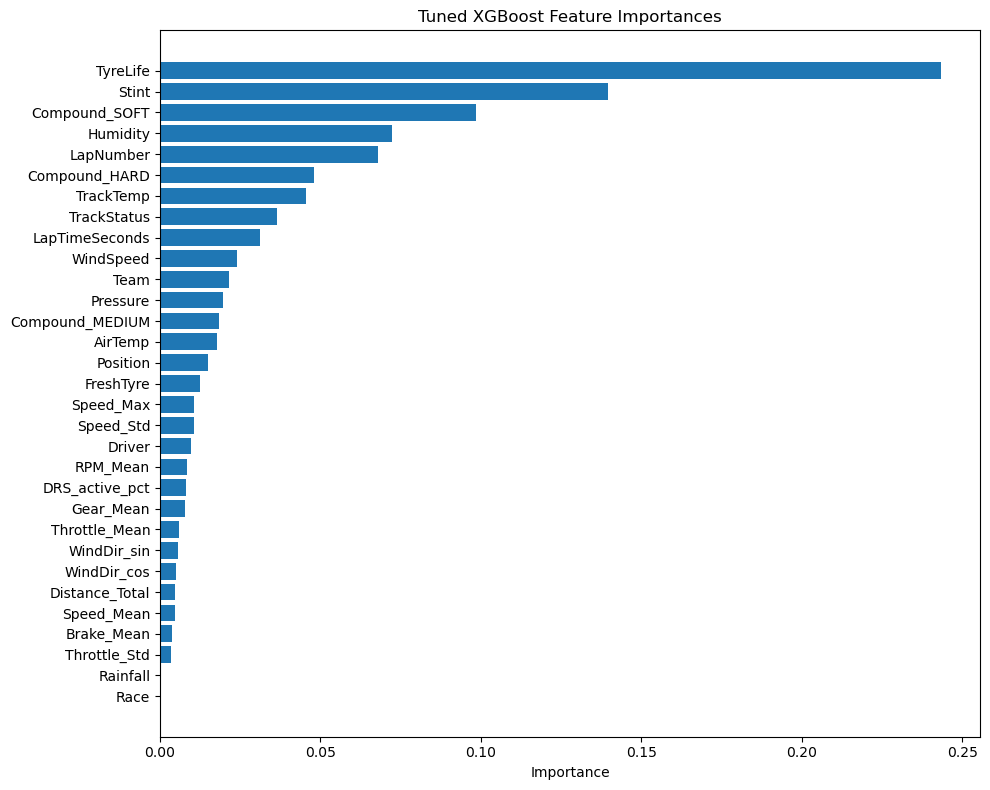

In [273]:
# Get feature importances and sort them
importances_tuned = best_xgb.feature_importances_
indices_tuned = np.argsort(importances_tuned)

plt.figure(figsize=(10, 8))
plt.barh(np.array(X_train.columns)[indices_tuned], importances_tuned[indices_tuned])
plt.title("Tuned XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Result: Poor generalization<br>
Pivot to classification problem, trying to predict whether pit in 5 laps.

#### Reframe as classification task

In [274]:
df_encoded_copy = df_encoded.copy()

In [275]:
# Binary label: 1 if pitting in next 5 laps (including this lap), else 0
df_encoded_copy['PitNext5'] = (df_encoded_copy['LapsTilPit'] <= 5).astype(int)

In [276]:
df_encoded_copy['PitNext5'].value_counts()

PitNext5
0    3071
1    1343
Name: count, dtype: int64

In [277]:
feature_cols = [col for col in df_encoded_copy.columns if col not in ['LapsTilPit', 'Year', 'PitNext5']]

# Create a copy to avoid modifying original
X = df_encoded_copy[feature_cols]
y = df_encoded_copy['PitNext5']

# Step 1: Split off test set (15%)
X_temp, X_test_cl, y_temp, y_test_cl = train_test_split(
    X, y,
    test_size=0.15,
    random_state=111,
    stratify=y
)

# Step 2: Split remaining into train and validation (85% → 70/15)
# 0.176 is ~15% of the original full set (0.15 / 0.85)
X_train_cl, X_val_cl, y_train_cl, y_val_cl = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=111,
    stratify=y_temp
)

print("Train:", X_train_cl.shape)
print("Validation:", X_val_cl.shape)
print("Test:", X_test_cl.shape)

Train: (3090, 31)
Validation: (661, 31)
Test: (663, 31)


In [278]:
# # Train, val, test split
# train_df_cl = df_encoded_copy[df_encoded_copy['Year'].isin([2022, 2023])]
# val_df_cl   = df_encoded_copy[df_encoded_copy['Year'] == 2024]
# test_df_cl  = df_encoded_copy[df_encoded_copy['Year'] == 2025]

In [279]:
# # Split sets into features and target
# feature_cols = [col for col in train_df_cl.columns if col not in ['LapsTilPit', 'Year', 'PitNext5']]

# # Training set
# X_train_cl = train_df_cl[feature_cols]
# y_train_cl = train_df_cl['PitNext5']

# # Validation set
# X_val_cl = val_df_cl[feature_cols]
# y_val_cl = val_df_cl['PitNext5']

# # Test set
# X_test_cl = test_df_cl[feature_cols]
# y_test_cl = test_df_cl['PitNext5']

In [280]:
# print(X_train_cl.shape)
# print(y_train_cl.shape)
# print(X_val_cl.shape)
# print(y_val_cl.shape)
# print(X_test_cl.shape)
# print(y_test_cl.shape)

#### Train XGBoost classifier model

In [281]:
# Train
xgb_base_cl = XGBClassifier()
xgb_base_cl.fit(X_train_cl, y_train_cl)

# Predict
y_val_pred_cl = xgb_base_cl.predict(X_val_cl)

# Evaluate
print("XGBoost Classifier Validation Set Performance:\n")
print(confusion_matrix(y_val_cl, y_val_pred_cl))
print(classification_report(y_val_cl, y_val_pred_cl))

XGBoost Classifier Validation Set Performance:

[[444  16]
 [ 35 166]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       460
           1       0.91      0.83      0.87       201

    accuracy                           0.92       661
   macro avg       0.92      0.90      0.91       661
weighted avg       0.92      0.92      0.92       661



#### Tune classifier model

In [282]:
# Class imbalance -> calculate ratio of negative to positive class
ratio = (y_train_cl == 0).sum() / (y_train_cl == 1).sum()
ratio

2.2872340425531914

In [283]:
param_grid_cl = {
    'n_estimators': [100, 200, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'scale_pos_weight': [ratio, ratio*0.8, ratio*1.2],
}

In [284]:
search_cl = RandomizedSearchCV(
    xgb_base_cl,
    param_distributions=param_grid_cl,
    n_iter=60,
    scoring='f1_weighted',
    cv=3,
    verbose=1,
    random_state=111,
    n_jobs=-1
)
search_cl.fit(X_train_cl, y_train_cl)

Fitting 3 folds for each of 60 candidates, totalling 180 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,60
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,111
,error_score,nan


In [285]:
best_xgb_cl = search_cl.best_estimator_
y_val_pred_cl_best = best_xgb_cl.predict(X_val_cl)

print(search_cl.best_params_)
print(confusion_matrix(y_val_cl, y_val_pred_cl_best))
print(classification_report(y_val_cl, y_val_pred_cl_best))

{'subsample': 1.0, 'scale_pos_weight': 2.2872340425531914, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
[[441  19]
 [ 31 170]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       460
           1       0.90      0.85      0.87       201

    accuracy                           0.92       661
   macro avg       0.92      0.90      0.91       661
weighted avg       0.92      0.92      0.92       661



#### Create more bins

In [286]:
def pit_bin(laps_til_pit):
    if laps_til_pit <= 5:
        return 0
    elif laps_til_pit <= 10:
        return 1
    elif laps_til_pit <= 20:
        return 2
    else:
        return 3

df_encoded_copy['PitBins'], laps_till_pit_bins = pd.qcut(df_encoded_copy['LapsTilPit'], 4, labels=[0,1,2,3], retbins=True)
print('Pit Bins')
laps_till_pit_bins

Pit Bins


array([ 1.,  5.,  9., 14., 31.])

In [287]:
print(df_encoded_copy['PitBins'].value_counts().sort_index())

PitBins
0    1343
1    1044
2    1083
3     944
Name: count, dtype: int64


In [288]:
feature_cols = [col for col in df_encoded_copy.columns if col not in ['LapsTilPit', 'Year', 'PitNext5', 'PitBins']]

# Create a copy to avoid modifying original
X = df_encoded_copy[feature_cols]
y = df_encoded_copy['PitBins']

# Step 1: Split off test set (15%)
X_temp, X_test_bins, y_temp, y_test_bins = train_test_split(
    X, y,
    test_size=0.15,
    random_state=111,
    stratify=y
)

# Step 2: Split remaining into train and validation (85% → 70/15)
# 0.176 is ~15% of the original full set (0.15 / 0.85)
X_train_bins, X_val_bins, y_train_bins, y_val_bins = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=111,
    stratify=y_temp
)

print("Train:", X_train_bins.shape)
print("Validation:", X_val_bins.shape)
print("Test:", X_test_bins.shape)

Train: (3090, 31)
Validation: (661, 31)
Test: (663, 31)


In [289]:
# # Train, val, test split
# train_df_bins = df_encoded_copy[df_encoded_copy['Year'].isin([2022, 2023])]
# val_df_bins   = df_encoded_copy[df_encoded_copy['Year'] == 2024]
# test_df_bins  = df_encoded_copy[df_encoded_copy['Year'] == 2025]

In [290]:
# # Split sets into features and target
# feature_cols = [col for col in train_df_bins.columns if col not in ['LapsTilPit', 'Year', 'PitNext5', 'PitBins']]

# # Training set
# X_train_bins = train_df_bins[feature_cols]
# y_train_bins = train_df_bins['PitBins']

# # Validation set
# X_val_bins = val_df_bins[feature_cols]
# y_val_bins = val_df_bins['PitBins']

# # Test set
# X_test_bins = test_df_bins[feature_cols]
# y_test_bins = test_df_bins['PitBins']

#### Train XGB multiclass model

In [291]:
# Train
xgb_multi = XGBClassifier(num_class=4)
xgb_multi.fit(X_train_bins, y_train_bins)

# Predict
y_val_pred_bins = xgb_multi.predict(X_val_bins)

# Evaluate
print("XGBoost Multiclass Validation Set Performance:\n")
print(confusion_matrix(y_val_bins, y_val_pred_bins))
print(classification_report(y_val_bins, y_val_pred_bins))

XGBoost Multiclass Validation Set Performance:

[[185  13   0   3]
 [ 19 123  14   0]
 [  1  30 119  12]
 [  4   0  11 127]]
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       201
           1       0.74      0.79      0.76       156
           2       0.83      0.73      0.78       162
           3       0.89      0.89      0.89       142

    accuracy                           0.84       661
   macro avg       0.84      0.83      0.83       661
weighted avg       0.84      0.84      0.84       661



In [292]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

In [293]:
search_mc = RandomizedSearchCV(
    estimator=xgb_multi,
    param_distributions=param_grid,
    n_iter=60,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=111
)
search_mc.fit(X_train_bins, y_train_bins)

Fitting 3 folds for each of 60 candidates, totalling 180 fits


,estimator,"XGBClassifier..._class=4, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,60
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,111
,error_score,nan


In [294]:
best_xgb_multi = search_mc.best_estimator_
y_val_pred_best = best_xgb_multi.predict(X_val_bins)

print("Best parameters:", search_mc.best_params_)
print(confusion_matrix(y_val_bins, y_val_pred_best))
print(classification_report(y_val_bins, y_val_pred_best))

Best parameters: {'subsample': 0.9, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
[[185  13   0   3]
 [ 18 121  17   0]
 [  0  32 115  15]
 [  4   1  12 125]]
              precision    recall  f1-score   support

           0       0.89      0.92      0.91       201
           1       0.72      0.78      0.75       156
           2       0.80      0.71      0.75       162
           3       0.87      0.88      0.88       142

    accuracy                           0.83       661
   macro avg       0.82      0.82      0.82       661
weighted avg       0.83      0.83      0.83       661



In [295]:
y_val_test_best = best_xgb_multi.predict(X_test_bins)

print("Best parameters:", search_mc.best_params_)
print(confusion_matrix(y_test_bins, y_val_test_best))
print(classification_report(y_test_bins, y_val_test_best))

Best parameters: {'subsample': 0.9, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
[[178  19   3   2]
 [ 24 113  16   4]
 [  3  14 130  15]
 [  1   3  16 122]]
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       202
           1       0.76      0.72      0.74       157
           2       0.79      0.80      0.80       162
           3       0.85      0.86      0.86       142

    accuracy                           0.82       663
   macro avg       0.82      0.82      0.82       663
weighted avg       0.82      0.82      0.82       663




--- WEIGHT ---


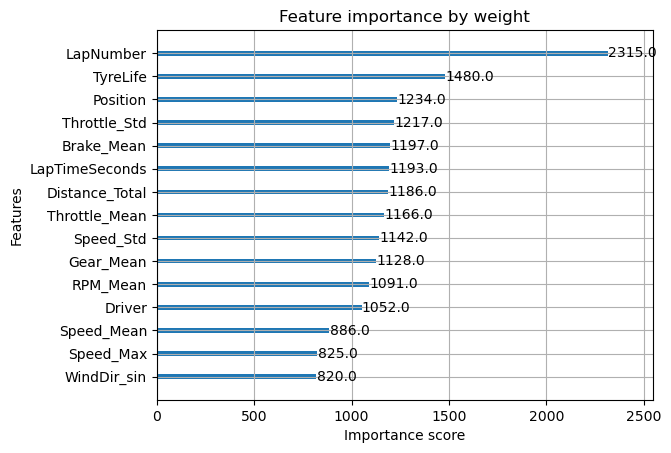


--- GAIN ---


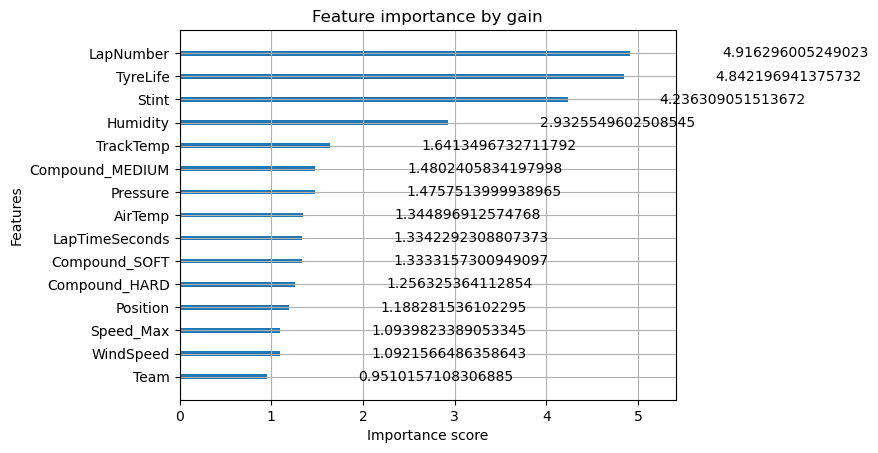


--- COVER ---


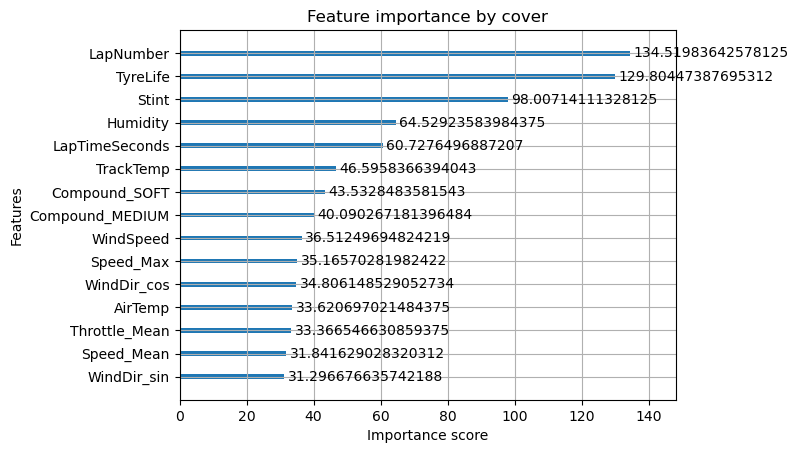

In [296]:
from xgboost import plot_importance

for t in ['weight', 'gain', 'cover']:
    print(f"\n--- {t.upper()} ---")
    plot_importance(best_xgb_multi, importance_type=t, max_num_features=15)
    plt.title(f"Feature importance by {t}")
    plt.show()

### Canada

#### Load cleaned data

In [297]:
df = pd.read_csv('data/f1_laps_canadian_clean.csv')

In [298]:
df.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Stint', 'LapTime', 'LapNumber',
       'Position', 'Compound', 'TyreLife', 'FreshTyre', 'TrackStatus',
       'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp',
       'WindDirection', 'WindSpeed', 'Speed_Mean', 'Speed_Max', 'Speed_Std',
       'RPM_Mean', 'Throttle_Mean', 'Throttle_Std', 'Brake_Mean', 'Gear_Mean',
       'Distance_Total', 'DRS_active_pct', 'LapsTilPit'],
      dtype='object')

#### Encode and standardize features

In [299]:
df.dtypes

Driver             object
Team               object
Year                int64
Race               object
Stint             float64
LapTime            object
LapNumber         float64
Position          float64
Compound           object
TyreLife          float64
FreshTyre            bool
TrackStatus         int64
AirTemp           float64
Humidity          float64
Pressure          float64
Rainfall             bool
TrackTemp         float64
WindDirection       int64
WindSpeed         float64
Speed_Mean        float64
Speed_Max         float64
Speed_Std         float64
RPM_Mean          float64
Throttle_Mean     float64
Throttle_Std      float64
Brake_Mean        float64
Gear_Mean         float64
Distance_Total    float64
DRS_active_pct    float64
LapsTilPit        float64
dtype: object

In [300]:
# Turn bool values into int
df['FreshTyre'] = df['FreshTyre'].astype(int)
df['Rainfall'] = df['Rainfall'].astype(int)

In [301]:
ordinal_cols = ['Stint', 'Position']  # leave as is
label = ['LapsTilPit']

label_encode_cols = ['Driver', 'Team', 'Race', 'TrackStatus']
one_hot_cols = ['Compound']

numerical_cols = ['LapTimeSeconds', 'LapNumber', 'TyreLife',
       'AirTemp', 'Humidity', 'Pressure', 'TrackTemp', 'WindSpeed',
       'Speed_Mean', 'Speed_Max', 'Speed_Std', 'Throttle_Mean', 'Throttle_Std',
       'RPM_Mean', 'Brake_Mean', 'Gear_Mean', 'Distance_Total', 'DRS_active_pct']

In [302]:
df_encoded = df.copy()

In [303]:
# Apply cyclical encoding
df_encoded['WindDir_sin'] = np.sin(np.deg2rad(df_encoded['WindDirection']))
df_encoded['WindDir_cos'] = np.cos(np.deg2rad(df_encoded['WindDirection']))

df_encoded = df_encoded.drop(columns=['WindDirection'])

In [304]:
# Label encode
for col in label_encode_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

In [305]:
# One-hot encode
df_encoded = pd.get_dummies(df_encoded, columns=one_hot_cols, drop_first=False)

# Find all new columns created by one-hot encoding
new_cols = [col for col in df_encoded.columns if any(prefix + '_' in col for prefix in one_hot_cols)]

# Cast these columns to int (0/1)
df_encoded[new_cols] = df_encoded[new_cols].astype(int)

In [306]:
df_encoded.columns

Index(['Driver', 'Team', 'Year', 'Race', 'Stint', 'LapTime', 'LapNumber',
       'Position', 'TyreLife', 'FreshTyre', 'TrackStatus', 'AirTemp',
       'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindSpeed',
       'Speed_Mean', 'Speed_Max', 'Speed_Std', 'RPM_Mean', 'Throttle_Mean',
       'Throttle_Std', 'Brake_Mean', 'Gear_Mean', 'Distance_Total',
       'DRS_active_pct', 'LapsTilPit', 'WindDir_sin', 'WindDir_cos',
       'Compound_HARD', 'Compound_INTERMEDIATE', 'Compound_MEDIUM',
       'Compound_SOFT', 'Compound_WET'],
      dtype='object')

In [307]:
df_encoded.loc[0]

Driver                                       27
Team                                         11
Year                                       2022
Race                                          0
Stint                                       1.0
LapTime                  0 days 00:01:23.396000
LapNumber                                   1.0
Position                                    1.0
TyreLife                                    1.0
FreshTyre                                     1
TrackStatus                                   0
AirTemp                                    20.0
Humidity                                   29.0
Pressure                                 1012.5
Rainfall                                      0
TrackTemp                                  41.4
WindSpeed                                   4.6
Speed_Mean                           186.651899
Speed_Max                                 307.0
Speed_Std                             73.131534
RPM_Mean                            9981

In [308]:
# Convert LapTime to seconds
df_encoded['LapTimeSeconds'] = pd.to_timedelta(df_encoded['LapTime']).dt.total_seconds()
df_encoded = df_encoded.drop(columns=['LapTime'])

df_encoded['LapTimeSeconds']

0        83.396
1        95.457
2        93.394
3        85.160
4        92.647
         ...   
5184    117.112
5185    115.527
5186    115.750
5187     87.108
5188     88.571
Name: LapTimeSeconds, Length: 5189, dtype: float64

In [309]:
# Standardize numerical columns
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

In [310]:
df_encoded[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
LapTimeSeconds,5189.0,-4.710478e-16,1.000096,-0.791231,-0.540451,-0.428975,0.223152,5.485889
LapNumber,5189.0,6.572760e-17,1.000096,-1.665933,-0.866411,-0.016920,0.832571,1.782003
TyreLife,5189.0,-6.572760e-17,1.000096,-1.267132,-0.753569,-0.240006,0.530339,4.467655
AirTemp,5189.0,-2.190920e-17,1.000096,-1.823711,-0.727760,-0.274263,1.086229,1.842057
Humidity,5189.0,-1.314552e-16,1.000096,-1.149201,-1.003322,-0.808816,0.795856,1.573879
Pressure,5189.0,1.112987e-14,1.000096,-1.669731,0.160649,0.256984,1.075838,1.111964
TrackTemp,5189.0,-7.230036e-16,1.000096,-1.725881,-0.793722,0.432270,1.252975,1.364429
WindSpeed,5189.0,-4.381840e-17,1.000096,-1.588553,-0.857697,-0.289253,0.604015,2.958997
Speed_Mean,5189.0,-2.190920e-17,1.000096,-4.052362,-0.413857,0.425967,0.613180,1.097433
Speed_Max,5189.0,-1.561030e-16,1.000096,-6.747151,-0.298930,-0.005829,0.404512,2.280358


#### Split into train, val, and test sets

In [311]:
feature_cols = [col for col in df_encoded.columns if col not in ['LapsTilPit', 'Year']]

# Create a copy to avoid modifying original
X = df_encoded[feature_cols]
y = df_encoded['LapsTilPit']

# Step 1: Split off test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=111
)

# Step 2: Split remaining into train and validation (85% → 70/15)
# 0.176 is ~15% of the original full set (0.15 / 0.85)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=111
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (3633, 33)
Validation: (777, 33)
Test: (779, 33)


In [312]:
# # Train, val, test split
# train_df = df_encoded[df_encoded['Year'].isin([2022, 2023])]
# val_df   = df_encoded[df_encoded['Year'] == 2024]
# test_df  = df_encoded[df_encoded['Year'] == 2025]

In [313]:
# print(train_df.shape)
# print(val_df.shape)
# print(test_df.shape)

In [314]:
# # Split sets into features and target
# feature_cols = [col for col in train_df.columns if col not in ['LapsTilPit', 'Year']]

# # Training set
# X_train = train_df[feature_cols]
# y_train = train_df['LapsTilPit']

# # Validation set
# X_val = val_df[feature_cols]
# y_val = val_df['LapsTilPit']

# # Test set
# X_test = test_df[feature_cols]
# y_test = test_df['LapsTilPit']

In [315]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(3633, 33)
(3633,)
(777, 33)
(777,)
(779, 33)
(779,)


#### Train XGBoost regression model

In [316]:
# Train XGBoost regressor
xgb_reg = XGBRegressor()
xgb_reg.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=True)

[0]	validation_0-rmse:9.87336
[1]	validation_0-rmse:8.63054
[2]	validation_0-rmse:7.75331
[3]	validation_0-rmse:7.07177
[4]	validation_0-rmse:6.64085
[5]	validation_0-rmse:6.38502
[6]	validation_0-rmse:6.17278
[7]	validation_0-rmse:5.83886
[8]	validation_0-rmse:5.64380


[9]	validation_0-rmse:5.50191
[10]	validation_0-rmse:5.31504
[11]	validation_0-rmse:5.15988
[12]	validation_0-rmse:4.94887
[13]	validation_0-rmse:4.89745
[14]	validation_0-rmse:4.71337
[15]	validation_0-rmse:4.63046
[16]	validation_0-rmse:4.58884
[17]	validation_0-rmse:4.58648
[18]	validation_0-rmse:4.50217
[19]	validation_0-rmse:4.39574
[20]	validation_0-rmse:4.36542
[21]	validation_0-rmse:4.30861
[22]	validation_0-rmse:4.23543
[23]	validation_0-rmse:4.12482
[24]	validation_0-rmse:4.09443
[25]	validation_0-rmse:4.07603
[26]	validation_0-rmse:4.04041
[27]	validation_0-rmse:4.01312
[28]	validation_0-rmse:4.00173
[29]	validation_0-rmse:3.98371
[30]	validation_0-rmse:3.96683
[31]	validation_0-rmse:3.94706
[32]	validation_0-rmse:3.91261
[33]	validation_0-rmse:3.87124
[34]	validation_0-rmse:3.84039
[35]	validation_0-rmse:3.83422
[36]	validation_0-rmse:3.83975
[37]	validation_0-rmse:3.83489
[38]	validation_0-rmse:3.78497
[39]	validation_0-rmse:3.75254
[40]	validation_0-rmse:3.73334
[41]	vali

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [317]:
# Predict
y_val_pred = xgb_reg.predict(X_val)
y_test_pred = xgb_reg.predict(X_test)

# Evaluate
print("Validation Results:")
print(f"RMSE: {root_mean_squared_error(y_val, y_val_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred):.3f}")
print(f"R2:   {r2_score(y_val, y_val_pred):.3f}")

print("\nTest Results:")
print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred):.3f}")
print(f"R2:   {r2_score(y_test, y_test_pred):.3f}")

Validation Results:
RMSE: 3.436
MAE:  2.321
R2:   0.913

Test Results:
RMSE: 3.649
MAE:  2.376
R2:   0.908


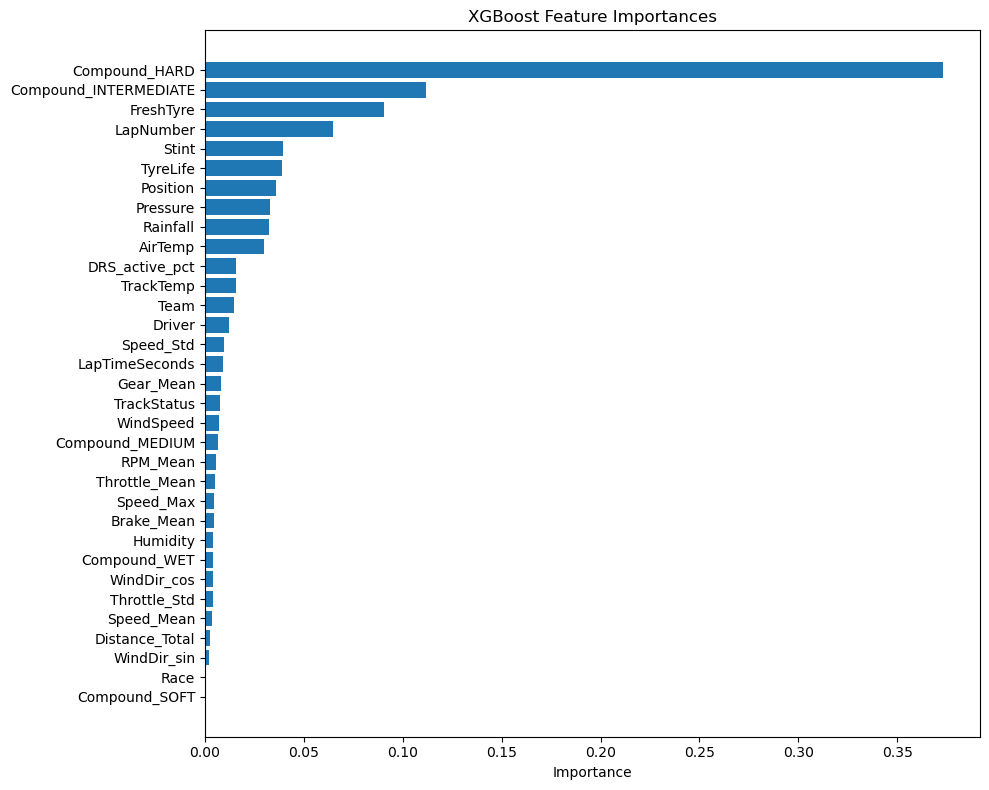

In [318]:
# Get feature importances and sort them
importances = xgb_reg.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.barh(np.array(X_train.columns)[indices], importances[indices])
plt.title("XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

#### Tune regression model

In [319]:
# Set up parameter grid
param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0]
}

In [320]:
# Set up RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_dist,
    n_iter=50,  # number of parameter settings sampled
    scoring='neg_root_mean_squared_error',  # for RMSE
    cv=3,
    verbose=1,
    random_state=111,
    n_jobs=-1
)

# Fit on data
search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,50
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,111
,error_score,nan


In [321]:
best_xgb = search.best_estimator_

print("Best parameters:", search.best_params_)

# Evaluate on validation and test
y_val_pred_tuned = best_xgb.predict(X_val)
y_test_pred_tuned = best_xgb.predict(X_test)

print("Validation Results:")
print(f"RMSE: {root_mean_squared_error(y_val, y_val_pred_tuned):.3f}")
print(f"MAE:  {mean_absolute_error(y_val, y_val_pred_tuned):.3f}")
print(f"R2:   {r2_score(y_val, y_val_pred_tuned):.3f}")

print("\nTest Results:")
print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred_tuned):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred_tuned):.3f}")
print(f"R2:   {r2_score(y_test, y_test_pred_tuned):.3f}")

Best parameters: {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Validation Results:
RMSE: 3.005
MAE:  1.833
R2:   0.933

Test Results:
RMSE: 3.005
MAE:  1.834
R2:   0.937


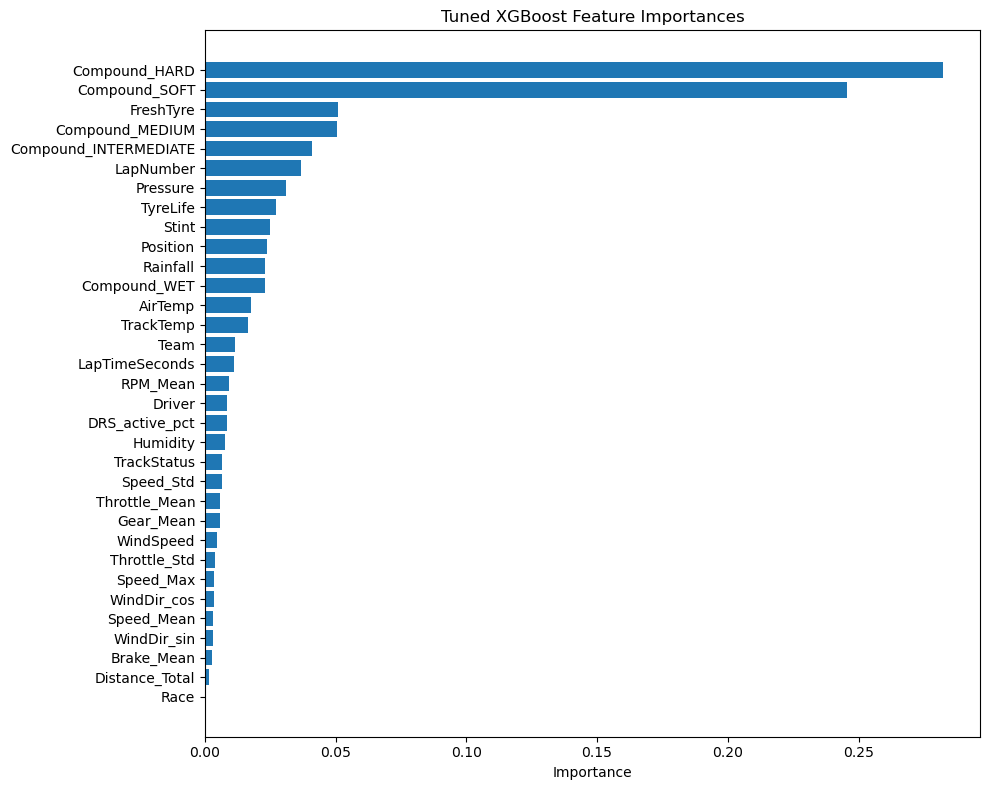

In [322]:
# Get feature importances and sort them
importances_tuned = best_xgb.feature_importances_
indices_tuned = np.argsort(importances_tuned)

plt.figure(figsize=(10, 8))
plt.barh(np.array(X_train.columns)[indices_tuned], importances_tuned[indices_tuned])
plt.title("Tuned XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Result: Poor generalization<br>
Pivot to classification problem, trying to predict whether pit in 5 laps.

#### Reframe as classification task

In [323]:
df_encoded_copy = df_encoded.copy()

In [324]:
# Binary label: 1 if pitting in next 5 laps (including this lap), else 0
df_encoded_copy['PitNext5'] = (df_encoded_copy['LapsTilPit'] <= 5).astype(int)

In [325]:
df_encoded_copy['PitNext5'].value_counts()

PitNext5
0    4089
1    1100
Name: count, dtype: int64

In [326]:
feature_cols = [col for col in df_encoded_copy.columns if col not in ['LapsTilPit', 'Year', 'PitNext5']]

# Create a copy to avoid modifying original
X = df_encoded_copy[feature_cols]
y = df_encoded_copy['PitNext5']

# Step 1: Split off test set (15%)
X_temp, X_test_cl, y_temp, y_test_cl = train_test_split(
    X, y,
    test_size=0.15,
    random_state=111,
    stratify=y
)

# Step 2: Split remaining into train and validation (85% → 70/15)
# 0.176 is ~15% of the original full set (0.15 / 0.85)
X_train_cl, X_val_cl, y_train_cl, y_val_cl = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=111,
    stratify=y_temp
)

print("Train:", X_train_cl.shape)
print("Validation:", X_val_cl.shape)
print("Test:", X_test_cl.shape)

Train: (3633, 33)
Validation: (777, 33)
Test: (779, 33)


In [327]:
# # Train, val, test split
# train_df_cl = df_encoded_copy[df_encoded_copy['Year'].isin([2022, 2023])]
# val_df_cl   = df_encoded_copy[df_encoded_copy['Year'] == 2024]
# test_df_cl  = df_encoded_copy[df_encoded_copy['Year'] == 2025]

In [328]:
# # Split sets into features and target
# feature_cols = [col for col in train_df_cl.columns if col not in ['LapsTilPit', 'Year', 'PitNext5']]

# # Training set
# X_train_cl = train_df_cl[feature_cols]
# y_train_cl = train_df_cl['PitNext5']

# # Validation set
# X_val_cl = val_df_cl[feature_cols]
# y_val_cl = val_df_cl['PitNext5']

# # Test set
# X_test_cl = test_df_cl[feature_cols]
# y_test_cl = test_df_cl['PitNext5']

In [329]:
# print(X_train_cl.shape)
# print(y_train_cl.shape)
# print(X_val_cl.shape)
# print(y_val_cl.shape)
# print(X_test_cl.shape)
# print(y_test_cl.shape)

#### Train XGBoost classifier model

In [330]:
# Train
xgb_base_cl = XGBClassifier()
xgb_base_cl.fit(X_train_cl, y_train_cl)

# Predict
y_val_pred_cl = xgb_base_cl.predict(X_val_cl)

# Evaluate
print("XGBoost Classifier Validation Set Performance:\n")
print(confusion_matrix(y_val_cl, y_val_pred_cl))
print(classification_report(y_val_cl, y_val_pred_cl))

XGBoost Classifier Validation Set Performance:

[[606   6]
 [ 38 127]]
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       612
           1       0.95      0.77      0.85       165

    accuracy                           0.94       777
   macro avg       0.95      0.88      0.91       777
weighted avg       0.94      0.94      0.94       777



#### Tune classifier model

In [331]:
# Class imbalance -> calculate ratio of negative to positive class
ratio = (y_train_cl == 0).sum() / (y_train_cl == 1).sum()
ratio

3.7181818181818183

In [332]:
param_grid_cl = {
    'n_estimators': [100, 200, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'scale_pos_weight': [ratio, ratio*0.8, ratio*1.2],
}

In [333]:
search_cl = RandomizedSearchCV(
    xgb_base_cl,
    param_distributions=param_grid_cl,
    n_iter=60,
    scoring='f1_weighted',
    cv=3,
    verbose=1,
    random_state=111,
    n_jobs=-1
)
search_cl.fit(X_train_cl, y_train_cl)

Fitting 3 folds for each of 60 candidates, totalling 180 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,60
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,111
,error_score,nan


In [334]:
best_xgb_cl = search_cl.best_estimator_
y_val_pred_cl_best = best_xgb_cl.predict(X_val_cl)

print(search_cl.best_params_)
print(confusion_matrix(y_val_cl, y_val_pred_cl_best))
print(classification_report(y_val_cl, y_val_pred_cl_best))

{'subsample': 0.7, 'scale_pos_weight': 4.461818181818182, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
[[598  14]
 [ 37 128]]
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       612
           1       0.90      0.78      0.83       165

    accuracy                           0.93       777
   macro avg       0.92      0.88      0.90       777
weighted avg       0.93      0.93      0.93       777



#### Create more bins

In [335]:
def pit_bin(laps_til_pit):
    if laps_til_pit <= 5:
        return 0
    elif laps_til_pit <= 10:
        return 1
    elif laps_til_pit <= 20:
        return 2
    else:
        return 3

df_encoded_copy['PitBins'], laps_till_pit_bins = pd.qcut(df_encoded_copy['LapsTilPit'], 4, labels=[0,1,2,3], retbins=True)
print('Pit Bins')
laps_till_pit_bins

Pit Bins


array([ 1.,  6., 13., 22., 68.])

In [336]:
print(df_encoded_copy['PitBins'].value_counts().sort_index())

PitBins
0    1308
1    1361
2    1308
3    1212
Name: count, dtype: int64


In [337]:
feature_cols = [col for col in df_encoded_copy.columns if col not in ['LapsTilPit', 'Year', 'PitNext5', 'PitBins']]

# Create a copy to avoid modifying original
X = df_encoded_copy[feature_cols]
y = df_encoded_copy['PitBins']

# Step 1: Split off test set (15%)
X_temp, X_test_bins, y_temp, y_test_bins = train_test_split(
    X, y,
    test_size=0.15,
    random_state=111,
    stratify=y
)

# Step 2: Split remaining into train and validation (85% → 70/15)
# 0.176 is ~15% of the original full set (0.15 / 0.85)
X_train_bins, X_val_bins, y_train_bins, y_val_bins = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=111,
    stratify=y_temp
)

print("Train:", X_train_bins.shape)
print("Validation:", X_val_bins.shape)
print("Test:", X_test_bins.shape)

Train: (3633, 33)
Validation: (777, 33)
Test: (779, 33)


In [338]:
# # Train, val, test split
# train_df_bins = df_encoded_copy[df_encoded_copy['Year'].isin([2022, 2023])]
# val_df_bins   = df_encoded_copy[df_encoded_copy['Year'] == 2024]
# test_df_bins  = df_encoded_copy[df_encoded_copy['Year'] == 2025]

In [339]:
# # Split sets into features and target
# feature_cols = [col for col in train_df_bins.columns if col not in ['LapsTilPit', 'Year', 'PitNext5', 'PitBins']]

# # Training set
# X_train_bins = train_df_bins[feature_cols]
# y_train_bins = train_df_bins['PitBins']

# # Validation set
# X_val_bins = val_df_bins[feature_cols]
# y_val_bins = val_df_bins['PitBins']

# # Test set
# X_test_bins = test_df_bins[feature_cols]
# y_test_bins = test_df_bins['PitBins']

#### Train XGB multiclass model

In [340]:
# Train
xgb_multi = XGBClassifier(num_class=4)
xgb_multi.fit(X_train_bins, y_train_bins)

# Predict
y_val_pred_bins = xgb_multi.predict(X_val_bins)

# Evaluate
print("XGBoost Multiclass Validation Set Performance:\n")
print(confusion_matrix(y_val_bins, y_val_pred_bins))
print(classification_report(y_val_bins, y_val_pred_bins))

XGBoost Multiclass Validation Set Performance:

[[164  23   8   1]
 [ 16 169  17   2]
 [  3   9 163  21]
 [  3   5   6 167]]
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       196
           1       0.82      0.83      0.82       204
           2       0.84      0.83      0.84       196
           3       0.87      0.92      0.90       181

    accuracy                           0.85       777
   macro avg       0.85      0.85      0.85       777
weighted avg       0.85      0.85      0.85       777



In [341]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

In [342]:
search_mc = RandomizedSearchCV(
    estimator=xgb_multi,
    param_distributions=param_grid,
    n_iter=60,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=111
)
search_mc.fit(X_train_bins, y_train_bins)

Fitting 3 folds for each of 60 candidates, totalling 180 fits


,estimator,"XGBClassifier..._class=4, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,60
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,111
,error_score,nan


In [343]:
best_xgb_multi = search_mc.best_estimator_
y_val_pred_best = best_xgb_multi.predict(X_val_bins)

print("Best parameters:", search_mc.best_params_)
print(confusion_matrix(y_val_bins, y_val_pred_best))
print(classification_report(y_val_bins, y_val_pred_best))

Best parameters: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
[[159  27   9   1]
 [ 15 170  16   3]
 [  4   8 171  13]
 [  1   5   6 169]]
              precision    recall  f1-score   support

           0       0.89      0.81      0.85       196
           1       0.81      0.83      0.82       204
           2       0.85      0.87      0.86       196
           3       0.91      0.93      0.92       181

    accuracy                           0.86       777
   macro avg       0.86      0.86      0.86       777
weighted avg       0.86      0.86      0.86       777



In [344]:
y_val_test_best = best_xgb_multi.predict(X_test_bins)

print("Best parameters:", search_mc.best_params_)
print(confusion_matrix(y_test_bins, y_val_test_best))
print(classification_report(y_test_bins, y_val_test_best))

Best parameters: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
[[173  18   5   1]
 [ 11 179  11   3]
 [  3  16 166  11]
 [  2   3   1 176]]
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       197
           1       0.83      0.88      0.85       204
           2       0.91      0.85      0.88       196
           3       0.92      0.97      0.94       182

    accuracy                           0.89       779
   macro avg       0.89      0.89      0.89       779
weighted avg       0.89      0.89      0.89       779




--- WEIGHT ---


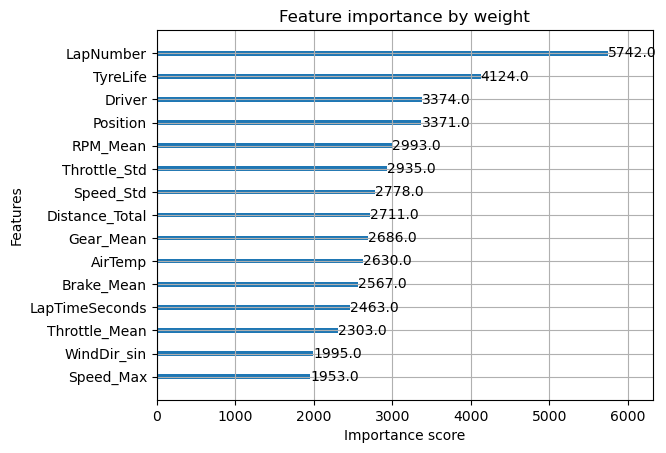


--- GAIN ---


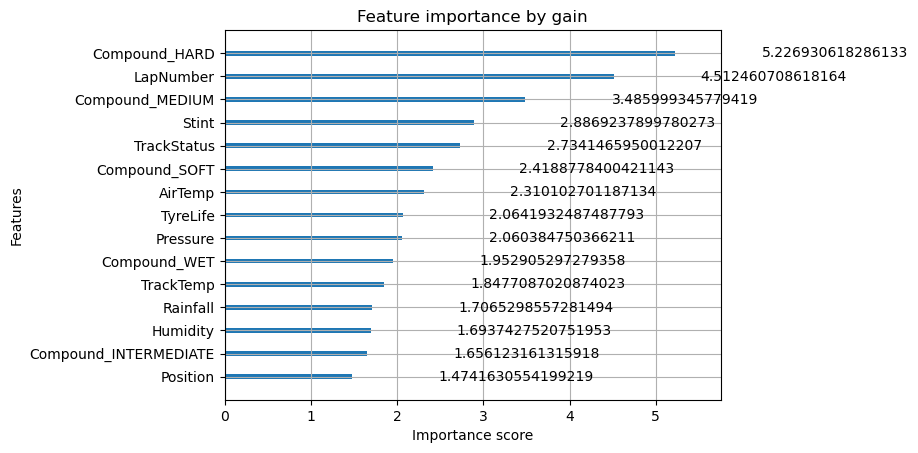


--- COVER ---


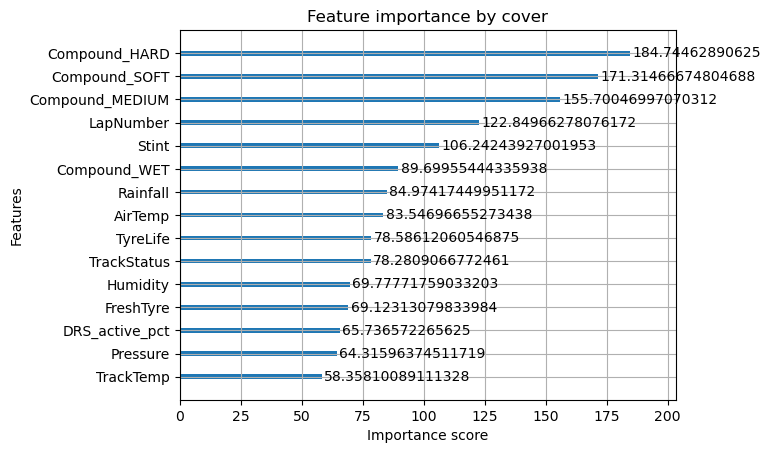

In [345]:
from xgboost import plot_importance

for t in ['weight', 'gain', 'cover']:
    print(f"\n--- {t.upper()} ---")
    plot_importance(best_xgb_multi, importance_type=t, max_num_features=15)
    plt.title(f"Feature importance by {t}")
    plt.show()